Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as any collaborators you worked with:

In [1]:
COLLABORATORS = ""

## To receive credit for this assignment, you must also fill out the [AI Use survey](https://forms.gle/ZhR5k8TdAeN8rj4CA)


---

In [2]:
from __future__ import print_function
%matplotlib inline
%precision 16
import numpy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from stability_diagrams import plot_stability_ssms
from stability_diagrams import plot_stability_lmm

# HW 5:  ODE Methods - Initial Value Problems

These questions will use a mixture of scipy routines and hand-rolled ODE solver methods (which you can use from the notes)

## Question 1 - The SIR model for Infectious diseases

ODE based models are a classical approach to understanding the spread of infectious diseases.

One of the pioneering models is the SIR model of [Kermack and McKendrick, (1927)](https://royalsocietypublishing.org/doi/10.1098/rspa.1927.0118) which is a mean-field theory for large populations that assumes the general population can be divided into three subgroups

* $S$: the number of susceptible patients
* $I$: the number of infected patients
* $R$: the number of recovered (or otherwise) patients

Given these definitions, the simplest dynamical systems for the three populations can be written

$$
\begin{aligned}
\frac{d S}{dt} &= -\alpha SI \\
\frac{d I}{dt} &= \alpha SI -\beta I\\
\frac{d R}{dt} &= \beta I \\
\end{aligned}
$$

where $\alpha$ is the infection rate per person, and $\beta$ is the recovery rate (hint: check the units) 

This is the original Kermack and McKendrick model and there are many more themes and variations.  However, here, we will explore just the simplest problem through a combination of Analysis and Numerical methods and use it to test different methods for ODE solvers.


**(a)** [4] First try to explain in words,  what this system of ODE's describes

## Answer:

The SIR model of epidemics is a three-dimensional model. It is a three-component, non-linear ODE initial value problem that describes how the sizes of three populations change over time. The variables are S, I, and R, where S is the susceptible population, I is the infected population, and R is the recovered population. The total population remains constant, so S + I + R = N (or 1 if scaled).

S, I, and R are dimensional quantities representing numbers or fractions of people, while the coefficients α and β are rate constants. Both α and β are non-negative parameters that control the relative rates of infection and recovery.

This system of first-order ODEs describes how the population transitions between these three groups over time. The term αSI represents the rate of new infections. Susceptible individuals become infected at this rate, so S decreases while I increases. Infected individuals recover at rate βI, so the change in I reflects the balance between new infections and recoveries. The recovered population R increases as infected individuals recover at the same rate β.




### Some analysis.  

Here we will conduct some elementary dimensional analysis to reduce the parameter space.  More detailed analysis of this system can be found  in Steve Strogatz' excellent text on [dynamical systems](https://smile.amazon.com/Nonlinear-Dynamics-Chaos-Applications-Nonlinearity/dp/0813349109/ref=dp_ob_image_bk)

**(b)** [2] Show that the SIR equations imply that   $S + I + R = N$  where $N$ is a constant (the total population of susceptible people that can all interact)

## Answer:
Given the three populations can be written:


\begin{aligned}
\frac{dS}{dt} &= -\alpha S I,\\
\frac{dI}{dt} &= \alpha S I - \beta I,\\
\frac{dR}{dt} &= \beta I,
\end{aligned}


we can add the right- and left-hand sides as follows:


\begin{aligned}
\frac{dS}{dt} + \frac{dI}{dt} + \frac{dR}{dt}
&= -\alpha S I + \alpha S I - \beta I + \beta I,\\
\frac{d}{dt}(S + I + R) &= 0.
\end{aligned}


Since the time derivative of \(S + I + R\) is zero, the sum \(S + I + R\) must be constant in time.  
We denote this constant by \(N\), the total population, so


S + I + R = N.

Starting from the conservation law 

\(S + I + R = N\), we define the scaled variables

\begin{aligned}
s = \frac{S}{N},  \;  i = \frac{I}{N}, \; r = \frac{R}{N}\\
\end{aligned}

Differentiating each with respect to time we have:

\begin{aligned}
\frac{ds}{dt} &= \frac{dS}{dt} \frac{1}{N},\ \frac{di}{dt} &= \frac{dI}{dt} \frac{1}{N},\  \frac{dr}{dt} &= \frac{dR}{dt} \frac{1}{N}
\end{aligned}

Multiplying both sides of the conservation law by 1/N
\begin{aligned}
\frac{1}{N} \frac{d}{dt}(S + I + R) &= \frac{1}{N} (0) \\
\end{aligned}

\begin{aligned}
\frac{d}{dt}(\frac{S}{N} + \frac{I}{N} + \frac{R}{N}) &= 0\\
\end{aligned}

and substituting in the scaled variables gives

\begin{aligned}
\frac{d}{dt}(s + i + r) = 0,\\
\end{aligned}

Integrating that with respect to time:
\begin{aligned}
\ (s + i + r) = constant
\end{aligned}

Initially, the whole population is distributed among the three compartments, so:

Since \s(0) + i(0) + r(0) = 1\, we have
\begin{aligned}
\ s(0) + i(0) + r(0) &= \frac{S_0+I_0+R_0}{dt} &= \frac{N}{N} &= 1\\
\end{aligned}

\begin{aligned}
\ s + i + r = 1.\\
\end{aligned}

Thus, in the scaled (dimensionless) form of the model, the total population is normalized to 1.





**(c)**  [4] Show that under  the change of variables (linear scaling of the variables)

$$
\begin{matrix}
    S = N s, & I = Ni, & R = Nr, & t = \tau\frac{1}{\alpha N} \\
\end{matrix}
$$

The original equations can be rewritten as the scaled equations 

$$
\begin{align}
    \frac{d s}{d\tau} &= -si\\
    \frac{d i}{d\tau} &= (s - s^*)i  \\
    \frac{d r}{d\tau} & = s^* i \\
\end{align}
$$

where 
$$
    s^* = \frac{\beta}{\alpha N}
$$



**Notes**,  
* if we write $s = S/N$ etc. then $s$ is simply the fraction of the total population that is susceptible.  
* Also show that $s + i + r = 1$.
* this scaling reduces a two-parameter problem to a one parameter problem where the only variable is $s^*$



## Answer:

We nondimensionalize the SIR system by scaling the state variables by the constant population N:

\begin{aligned}
s = \frac{S}{N},  \;  i = \frac{I}{N}, \; r = \frac{R}{N}\\
\end{aligned}

so summing left-hand sides and right hands sides
\begin{aligned}
s + i + r = \frac{S}{N} + \frac{I}{N} + \frac{R}{N} = \frac{N}{N} = 1\\
\end{aligned}

Substituting 
\begin{aligned}
S=Ns,  \; I=Ni,   \; R=Nr 
\end{aligned}

into the original equations and dividing by N
\begin{aligned}
\frac{ds}{dt} = -\alpha N s i, \quad 
\frac{di}{dt} = \alpha N s i - \beta i, \quad 
\frac{dr}{dt} = \beta i.
\end{aligned}


Introducing the dimensionless time 
\begin{aligned}
\tau = \alpha N t (so \; that \frac{d}{dt} =(\alpha N)\frac{d}{dτ})
\end{aligned}

removes the prefactor, yielding
\begin{aligned}
\frac{ds}{dτ}=−si,\quad 
\frac{di}{dτ}=si−\frac{\beta}{\alpha N}i, \quad
\frac{dr}{dτ}= \frac{\beta}{\alpha N}i
\end{aligned}​	

Defining the single parameter 
$s^*$ = \beta/(\alpha N) reduces the model to
\begin{aligned}
\frac{ds}{d\tau} = -s i, \quad 
\frac{di}{d\tau} = (s - s^*) i, \quad 
\frac{dr}{d\tau} = s^* i, \quad s + i + r = 1,
\end{aligned}
which shows that the two rates α,β (and the population N) collapse into the single threshold parameter $s^*$.


**(d)**  [2] Given that $s^*$ is a constant that only depends on the infection rate per capita $\alpha$, the recovery rate $\beta$ and the total population $N$,  interpret the equation for the change in the number of infections

$$
    \frac{d i}{d\tau} = (s - s^*) i
$$
as a function of the susceptible fraction of the population $s$.

## Answer:
### Q1(d)

From the scaled SIR system, the change in the fraction of infected individuals over scaled time τ is given by:

di/dτ = (s − s*) · i

where  
- s is the fraction of the population that is susceptible,  
- i is the fraction infected, and  
- s* = β / (αN) is a constant determined by the infection and recovery rates.

The rate of change of the infected population wll depend on the difference (s − s*):

• When s > s*, di/dτ > 0 and infections grow.  
• When s = s*, di/dτ = 0 and infections reach their peak.  
• When s < s*, di/dτ < 0 and infections decline.

So s* represents the **critical threshold** of susceptibles below which the disease can no longer spread. This is the point where each infected person infects, on average, less than one new individual, and the epidemic begins to die out.


### Numerical Methods

we will now explore the behavior of this model numerically using a range of our basic algorithms by solving the scaled dynamical system

$$
    \frac{d\mathbf{u}}{dt} = \mathbf{F}(t,\mathbf{u}, s^*),\quad\mathbf{u}(0)=\mathbf{u}_0
$$

where 
$$
    \mathbf{u} = \begin{bmatrix} s \\ i \\ r \\ \end{bmatrix}, \quad 
    \mathbf{F}(t,\mathbf{u},s^*) = \begin{bmatrix} -si \\ (s - s^*)i \\ s^*i \\ \end{bmatrix}
$$

**(e)** [4] Write function to return the RHS of the scaled dynamical system $\mathbf{F}(t,\mathbf{u},s^*)$ as a numpy array

In [3]:
def F(t, u, s_star):
    """ RHS of scaled SIR model of Kermack and McKendrick
    
    parameters
    ----------
        t: float
            time (just a dummy variable here because this is an autonomous system)
        u: numpy array
            array of scaled [ s, i, r ] values such that sum(u) = 1 
            (and s,i, r are fractions of the total population N)
        s_star: float
            scaled critical susceptible population = \beta/(\alpha N)
            
    returns:
        F(u): numpy array
    """
    # Extract state variables
    s = u[0]
    i = u[1]
    r = u[2]

    # Compute derivatives
    ds_dtau = -s * i
    di_dtau = (s - s_star) * i
    dr_dtau = s_star * i

     # Return as numpy array
    return numpy.array([ds_dtau, di_dtau, dr_dtau])


In [4]:
# noodle space for code

In [5]:
# testing cell
# Let's assume the critical level of immunity is 60% of the total population
s_star = 0.6

# let there initially be .01 % infected cases and no recovered
t = 0.
i_0 = 1.e-4
u_0 = numpy.array([1. - i_0, i_0, 0.0])
answer = numpy.array([-9.999000000000001e-05,  3.999000000000001e-05, 6.000000000000000e-05])
numpy.testing.assert_allclose(F(t, u_0, s_star), answer)
print('success!')

success!


**(f)** [10] Use scipy.integrate.solve_ivp (imported above as solve_ivp),  to solve the scaled dynamical system above with for <font color="red">$s^* = 0.6$</font> and initial condition

$$
    \mathbf{u}_0 = \begin{bmatrix} 1 - i_0\\ i_0 \\ 0\\ \end{bmatrix}
$$

where $i_0=10^{-5}$ is the initially infected proportion of the available population $N$

Integrate for $t\in[0, 50]$ and make a plot showing the evolution of $s(t)$, $i(t)$, ${r}(t)$ vs. time 

**For full credit your plot should show the following**
* show the actual time-steps chosen by the adaptive solver as well as a smooth solution (use dense_output=True) 
* the total cumulative number of cases at any time
* the time and infection level of the peak of the infection (hint: use the `events`, feature of solve_ivp)
* the maximum fraction of people infected

Explore the behavior of the solutions as a function of $s^*$ and $i_0$ and try to "flatten the curve" (we will try to make that more quantitative later). Also,  explore relative and absolute tolerances to convince yourself that your solutions are well resolved.

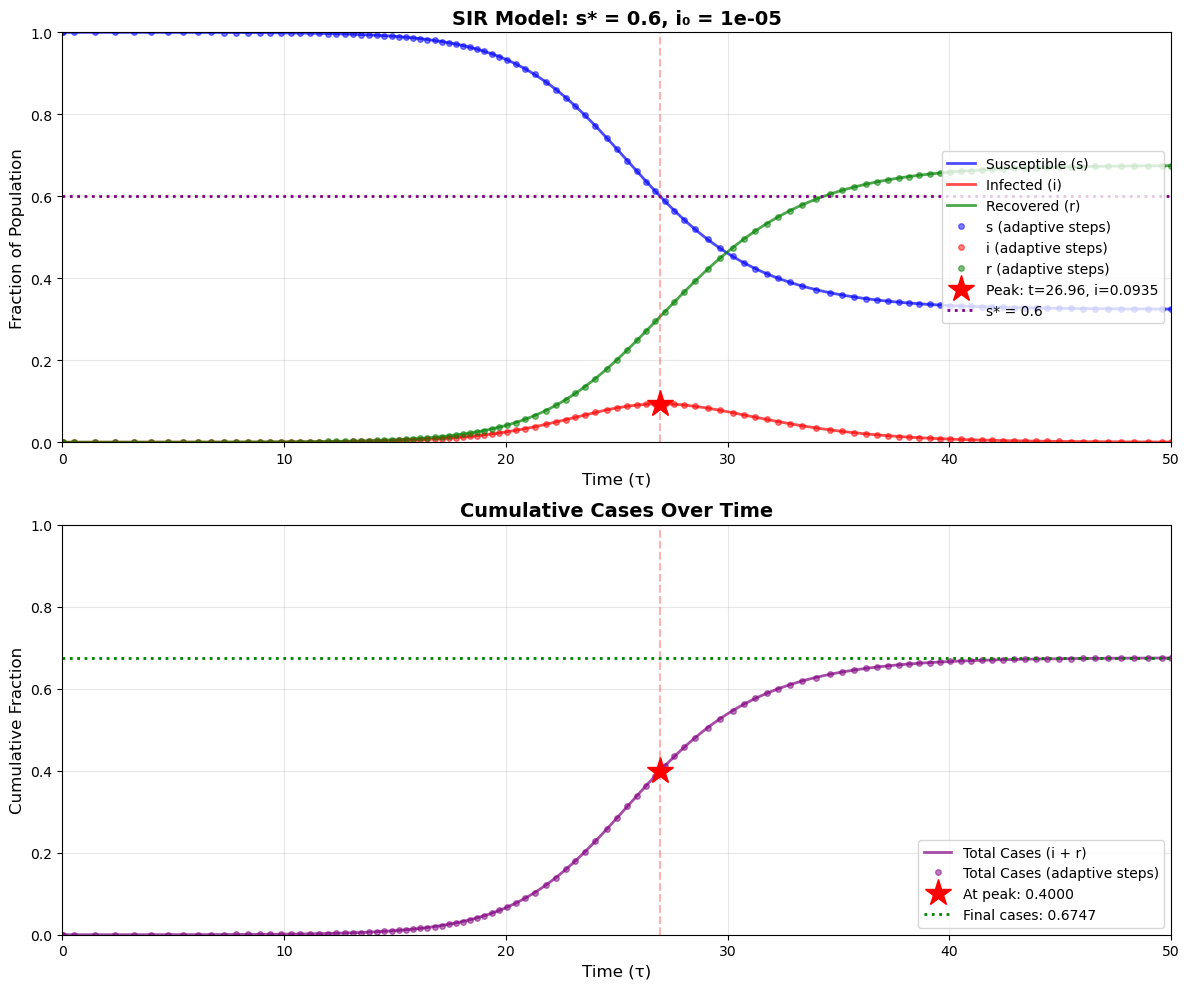

SIR Model Results (s* = 0.6, i₀ = 1e-05)
Number of adaptive time steps: 106
Maximum infected fraction: 0.093509 at t = 26.98
Peak time (s = s*): t = 26.96, i = 0.093511
Final recovered fraction: 0.674675
Final susceptible fraction: 0.324825
Total attack rate (final cases): 0.674675


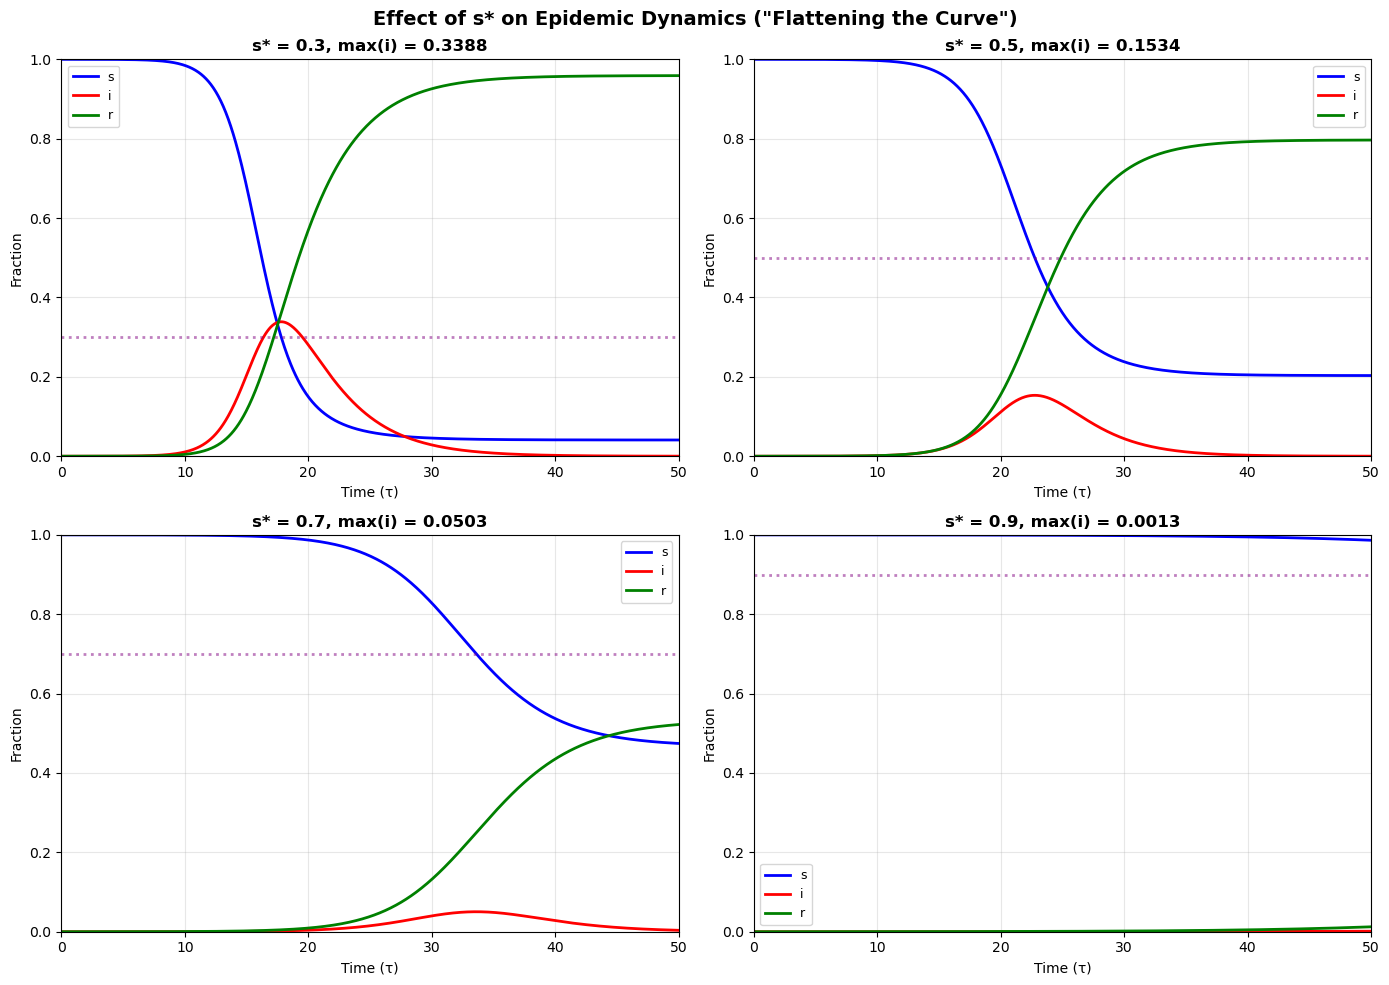


Key Observation: As s* increases (higher recovery rate or lower
infection rate), the peak infection decreases and occurs later.
This is 'flattening the curve'!


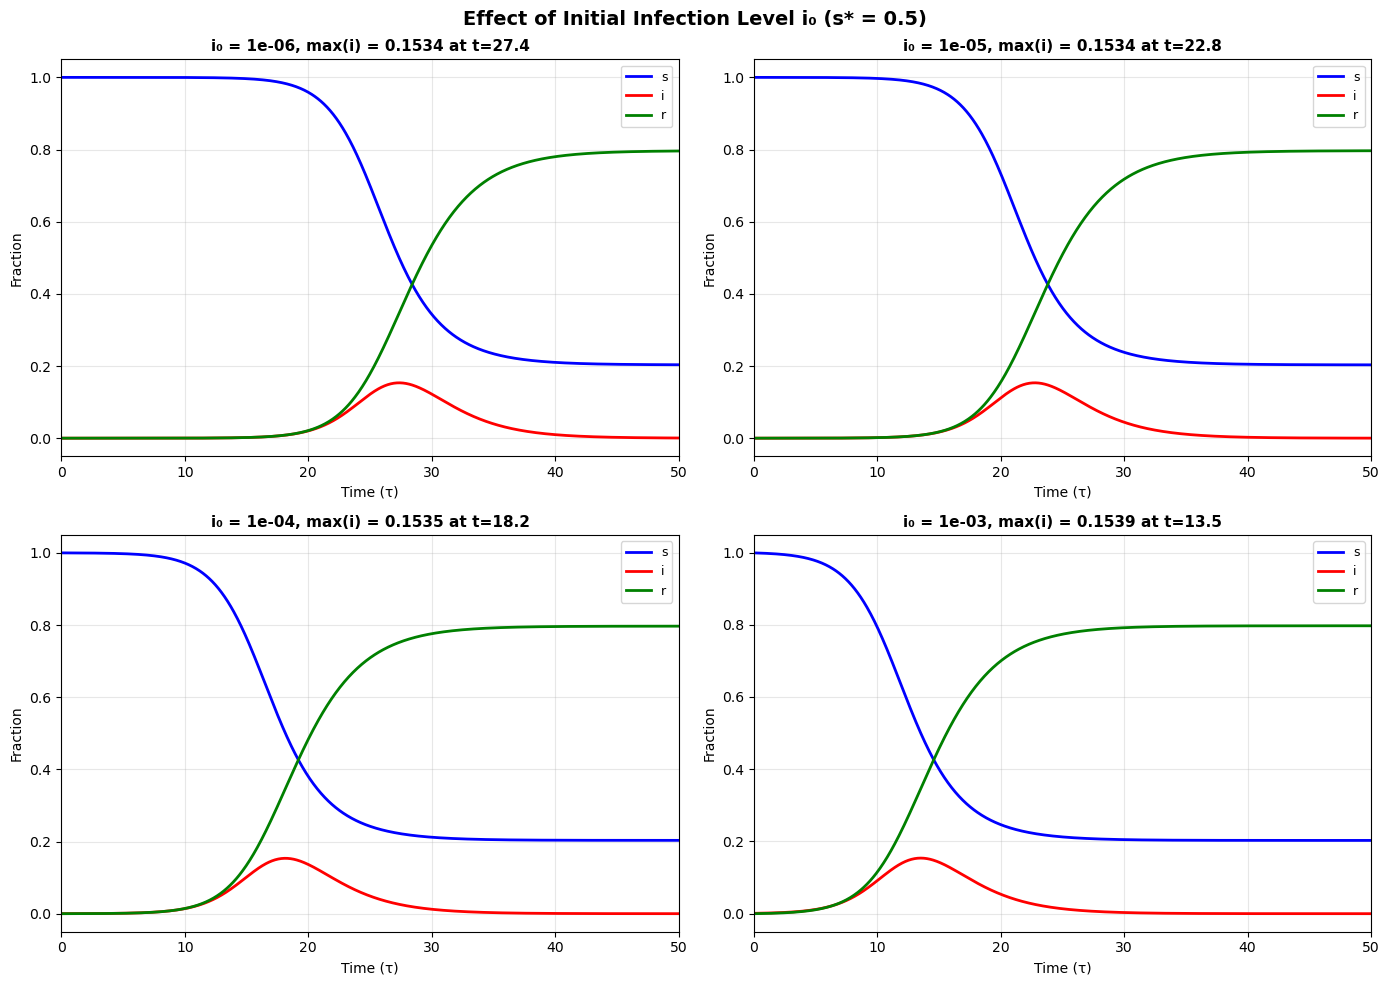


Key Observation: The initial infection level i₀ mainly affects
the timing of the epidemic, but not the peak height or final size.

TOLERANCE STUDY
rtol=1e-06, atol=1e-08: 44 steps, max(i)=0.09350943
rtol=1e-08, atol=1e-10: 106 steps, max(i)=0.09350937
rtol=1e-10, atol=1e-12: 263 steps, max(i)=0.09350938


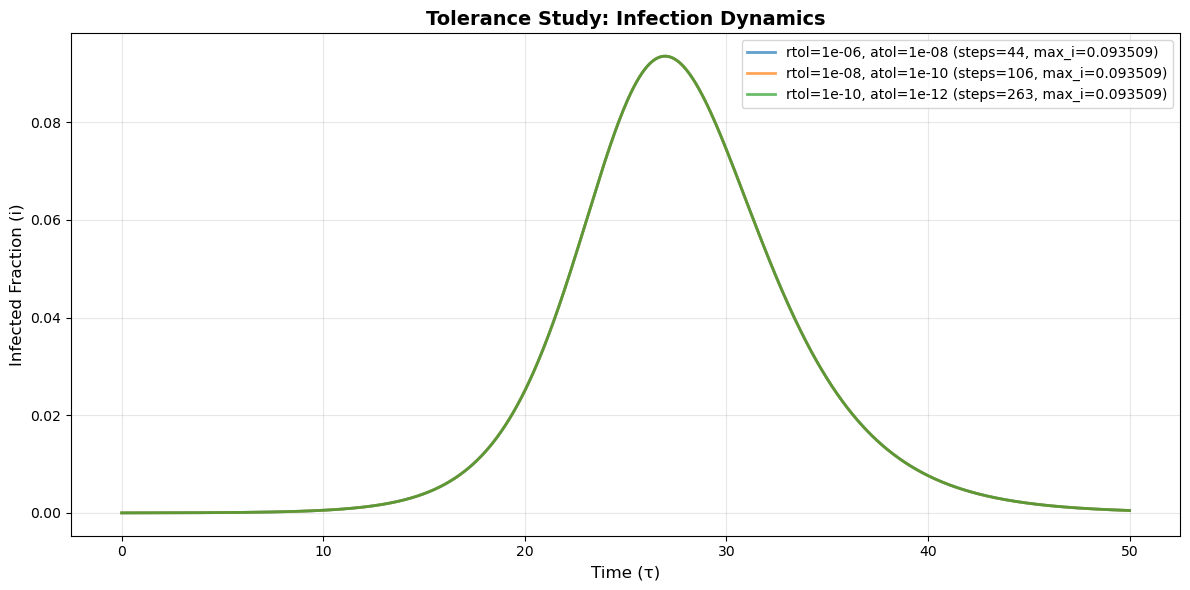


Conclusion: Results converge with rtol=1e-8, atol=1e-10


In [6]:
# Event function to detect peak of infection (di/dtau = 0)
def infection_peak(t, u):
    """
    Event function to detect when di/dtau = 0 (infection peak).
    The peak occurs when s = s_star.
    """
    s = u[0]
    return s - s_star

# Mark this as a terminal event (stop at first occurrence)
infection_peak.terminal = False
infection_peak.direction = -1  # Detect when s crosses s_star going downward

# Parameters
s_star = 0.6
i0 = 1e-5
u0 = numpy.array([1 - i0, i0, 0.0])
t_span = [0, 50]
t_eval = numpy.linspace(0, 50, 500)

# Solve the system with event detection
solution = solve_ivp(
    fun=lambda t, u: F(t, u, s_star),
    t_span=t_span,
    y0=u0,
    method='RK45',
    dense_output=True,
    events=infection_peak,
    rtol=1e-8,
    atol=1e-10
)

# Extract solutions
t_dense = numpy.linspace(0, 50, 1000)
u_dense = solution.sol(t_dense)
s_dense = u_dense[0]
i_dense = u_dense[1]
r_dense = u_dense[2]

# Extract actual time steps taken by the solver
t_steps = solution.t
u_steps = solution.y
s_steps = u_steps[0]
i_steps = u_steps[1]
r_steps = u_steps[2]

# Extract peak information
if len(solution.t_events[0]) > 0:
    t_peak = solution.t_events[0][0]
    u_peak = solution.sol(t_peak)
    i_peak = u_peak[1]
else:
    t_peak = None
    i_peak = None

# Calculate cumulative cases (total infected = i + r)
cumulative_cases_dense = i_dense + r_dense
cumulative_cases_steps = i_steps + r_steps

# Maximum fraction infected
max_i = numpy.max(i_dense)
t_max_i = t_dense[numpy.argmax(i_dense)]

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Individual compartments
ax1.plot(t_dense, s_dense, 'b-', linewidth=2, label='Susceptible (s)', alpha=0.7)
ax1.plot(t_dense, i_dense, 'r-', linewidth=2, label='Infected (i)', alpha=0.7)
ax1.plot(t_dense, r_dense, 'g-', linewidth=2, label='Recovered (r)', alpha=0.7)

# Plot actual time steps
ax1.plot(t_steps, s_steps, 'bo', markersize=4, alpha=0.5, label='s (adaptive steps)')
ax1.plot(t_steps, i_steps, 'ro', markersize=4, alpha=0.5, label='i (adaptive steps)')
ax1.plot(t_steps, r_steps, 'go', markersize=4, alpha=0.5, label='r (adaptive steps)')

# Mark the peak
if t_peak is not None:
    ax1.plot(t_peak, i_peak, 'r*', markersize=20, 
             label=f'Peak: t={t_peak:.2f}, i={i_peak:.4f}')
    ax1.axvline(x=t_peak, color='red', linestyle='--', alpha=0.3)

# Mark s* threshold
ax1.axhline(y=s_star, color='purple', linestyle=':', linewidth=2, 
            label=f's* = {s_star}')

ax1.set_xlabel('Time (τ)', fontsize=12)
ax1.set_ylabel('Fraction of Population', fontsize=12)
ax1.set_title(f'SIR Model: s* = {s_star}, i₀ = {i0}', fontsize=14, fontweight='bold')
ax1.legend(loc='right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 50])
ax1.set_ylim([0, 1])

# Plot 2: Cumulative cases
ax2.plot(t_dense, cumulative_cases_dense, 'purple', linewidth=2, 
         label='Total Cases (i + r)', alpha=0.7)
ax2.plot(t_steps, cumulative_cases_steps, 'o', color='purple', 
         markersize=4, alpha=0.5, label='Total Cases (adaptive steps)')

# Mark the peak infection time on cumulative plot
if t_peak is not None:
    cumulative_at_peak = solution.sol(t_peak)[1] + solution.sol(t_peak)[2]
    ax2.plot(t_peak, cumulative_at_peak, 'r*', markersize=20, 
             label=f'At peak: {cumulative_at_peak:.4f}')
    ax2.axvline(x=t_peak, color='red', linestyle='--', alpha=0.3)

# Final cumulative cases
final_cases = r_dense[-1]
ax2.axhline(y=final_cases, color='green', linestyle=':', linewidth=2,
            label=f'Final cases: {final_cases:.4f}')

ax2.set_xlabel('Time (τ)', fontsize=12)
ax2.set_ylabel('Cumulative Fraction', fontsize=12)
ax2.set_title('Cumulative Cases Over Time', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 50])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('sir_model_s_star_0.6.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("="*60)
print(f"SIR Model Results (s* = {s_star}, i₀ = {i0})")
print("="*60)
print(f"Number of adaptive time steps: {len(t_steps)}")
print(f"Maximum infected fraction: {max_i:.6f} at t = {t_max_i:.2f}")
if t_peak is not None:
    print(f"Peak time (s = s*): t = {t_peak:.2f}, i = {i_peak:.6f}")
print(f"Final recovered fraction: {r_dense[-1]:.6f}")
print(f"Final susceptible fraction: {s_dense[-1]:.6f}")
print(f"Total attack rate (final cases): {final_cases:.6f}")
print("="*60)




## Exploring Different Parameters

#Exploring how changing $s^*$ and $i_0$ affects the epidemic dynamics:


# Explore different s_star values to "flatten the curve"
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

s_star_values = [0.3, 0.5, 0.7, 0.9]
i0 = 1e-5

for idx, s_star_test in enumerate(s_star_values):
    u0_test = numpy.array([1 - i0, i0, 0.0])
    
    sol = solve_ivp(
        fun=lambda t, u: F(t, u, s_star_test),
        t_span=[0, 50],
        y0=u0_test,
        method='RK45',
        dense_output=True,
        rtol=1e-8,
        atol=1e-10
    )
    
    t_plot = numpy.linspace(0, 50, 1000)
    u_plot = sol.sol(t_plot)
    
    axes[idx].plot(t_plot, u_plot[0], 'b-', linewidth=2, label='s')
    axes[idx].plot(t_plot, u_plot[1], 'r-', linewidth=2, label='i')
    axes[idx].plot(t_plot, u_plot[2], 'g-', linewidth=2, label='r')
    axes[idx].axhline(y=s_star_test, color='purple', linestyle=':', 
                      linewidth=2, alpha=0.5)
    
    max_i_test = numpy.max(u_plot[1])
    axes[idx].set_title(f's* = {s_star_test}, max(i) = {max_i_test:.4f}', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Time (τ)', fontsize=10)
    axes[idx].set_ylabel('Fraction', fontsize=10)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 50])
    axes[idx].set_ylim([0, 1])

plt.suptitle('Effect of s* on Epidemic Dynamics ("Flattening the Curve")', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sir_flatten_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observation: As s* increases (higher recovery rate or lower")
print("infection rate), the peak infection decreases and occurs later.")
print("This is 'flattening the curve'!")



# Explore different initial infection levels
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

s_star = 0.5
i0_values = [1e-6, 1e-5, 1e-4, 1e-3]

for idx, i0_test in enumerate(i0_values):
    u0_test = numpy.array([1 - i0_test, i0_test, 0.0])
    
    sol = solve_ivp(
        fun=lambda t, u: F(t, u, s_star),
        t_span=[0, 50],
        y0=u0_test,
        method='RK45',
        dense_output=True,
        rtol=1e-8,
        atol=1e-10
    )
    
    t_plot = numpy.linspace(0, 50, 1000)
    u_plot = sol.sol(t_plot)
    
    axes[idx].plot(t_plot, u_plot[0], 'b-', linewidth=2, label='s')
    axes[idx].plot(t_plot, u_plot[1], 'r-', linewidth=2, label='i')
    axes[idx].plot(t_plot, u_plot[2], 'g-', linewidth=2, label='r')
    
    max_i_test = numpy.max(u_plot[1])
    t_max = t_plot[numpy.argmax(u_plot[1])]
    axes[idx].set_title(f'i₀ = {i0_test:.0e}, max(i) = {max_i_test:.4f} at t={t_max:.1f}', 
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Time (τ)', fontsize=10)
    axes[idx].set_ylabel('Fraction', fontsize=10)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 50])

plt.suptitle(f'Effect of Initial Infection Level i₀ (s* = {s_star})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sir_initial_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observation: The initial infection level i₀ mainly affects")
print("the timing of the epidemic, but not the peak height or final size.")





# Tolerance study
print("\n" + "="*60)
print("TOLERANCE STUDY")
print("="*60)

s_star = 0.6
i0 = 1e-5
u0 = numpy.array([1 - i0, i0, 0.0])

tolerances = [(1e-6, 1e-8), (1e-8, 1e-10), (1e-10, 1e-12)]

fig, ax = plt.subplots(figsize=(12, 6))

for rtol, atol in tolerances:
    sol = solve_ivp(
        fun=lambda t, u: F(t, u, s_star),
        t_span=[0, 50],
        y0=u0,
        method='RK45',
        dense_output=True,
        rtol=rtol,
        atol=atol
    )
    
    t_plot = numpy.linspace(0, 50, 1000)
    u_plot = sol.sol(t_plot)
    
    max_i = numpy.max(u_plot[1])
    n_steps = len(sol.t)
    
    ax.plot(t_plot, u_plot[1], linewidth=2, alpha=0.7,
            label=f'rtol={rtol:.0e}, atol={atol:.0e} (steps={n_steps}, max_i={max_i:.6f})')
    
    print(f"rtol={rtol:.0e}, atol={atol:.0e}: {n_steps} steps, max(i)={max_i:.8f}")

ax.set_xlabel('Time (τ)', fontsize=12)
ax.set_ylabel('Infected Fraction (i)', fontsize=12)
ax.set_title('Tolerance Study: Infection Dynamics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sir_tolerance_study.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nConclusion: Results converge with rtol=1e-8, atol=1e-10")
print("="*60)

**(g)** [8] Write your own code to solve the same system using any constant step-size method we discussed in class that is higher than 2nd order (you can use or modify any of the example codes from the notes and make sure it works for vector valued functions.   Your code should be able to use your function $F$ defined above. Make sure to choose a method that will work for the non-linear right-hand-side. We will test it against the output from solve_ivp with N steps uniform steps in $t\in[0,50]$.  What is the minimum number of steps does your routine take to pass the tests with a relative error of $10^{-4}$ and absolute error of $10^{-5}?.  You can control the number of steps taken with the `N=??` defined at the end of the cell.  **Extra Credit** determine the convergence rate of your method.

Testing RK4 solver against solve_ivp
N =   50: rel_error = 1.036133e-03, abs_error = 1.729226e-04 ✗ FAIL
N =  100: rel_error = 7.413283e-05, abs_error = 1.270779e-05 ✗ FAIL
N =  200: rel_error = 5.045544e-06, abs_error = 8.624418e-07 ✓ PASS
N =  500: rel_error = 1.524372e-07, abs_error = 2.585968e-08 ✓ PASS
N = 1000: rel_error = 1.346201e-07, abs_error = 4.252365e-09 ✓ PASS
N = 2000: rel_error = 1.357277e-07, abs_error = 2.879994e-09 ✓ PASS

Finding minimum N that passes the tests...
--------------------------------------------------------------------------------
✓ Minimum N = 110
  Relative error: 5.140980e-05
  Absolute error: 8.803039e-06


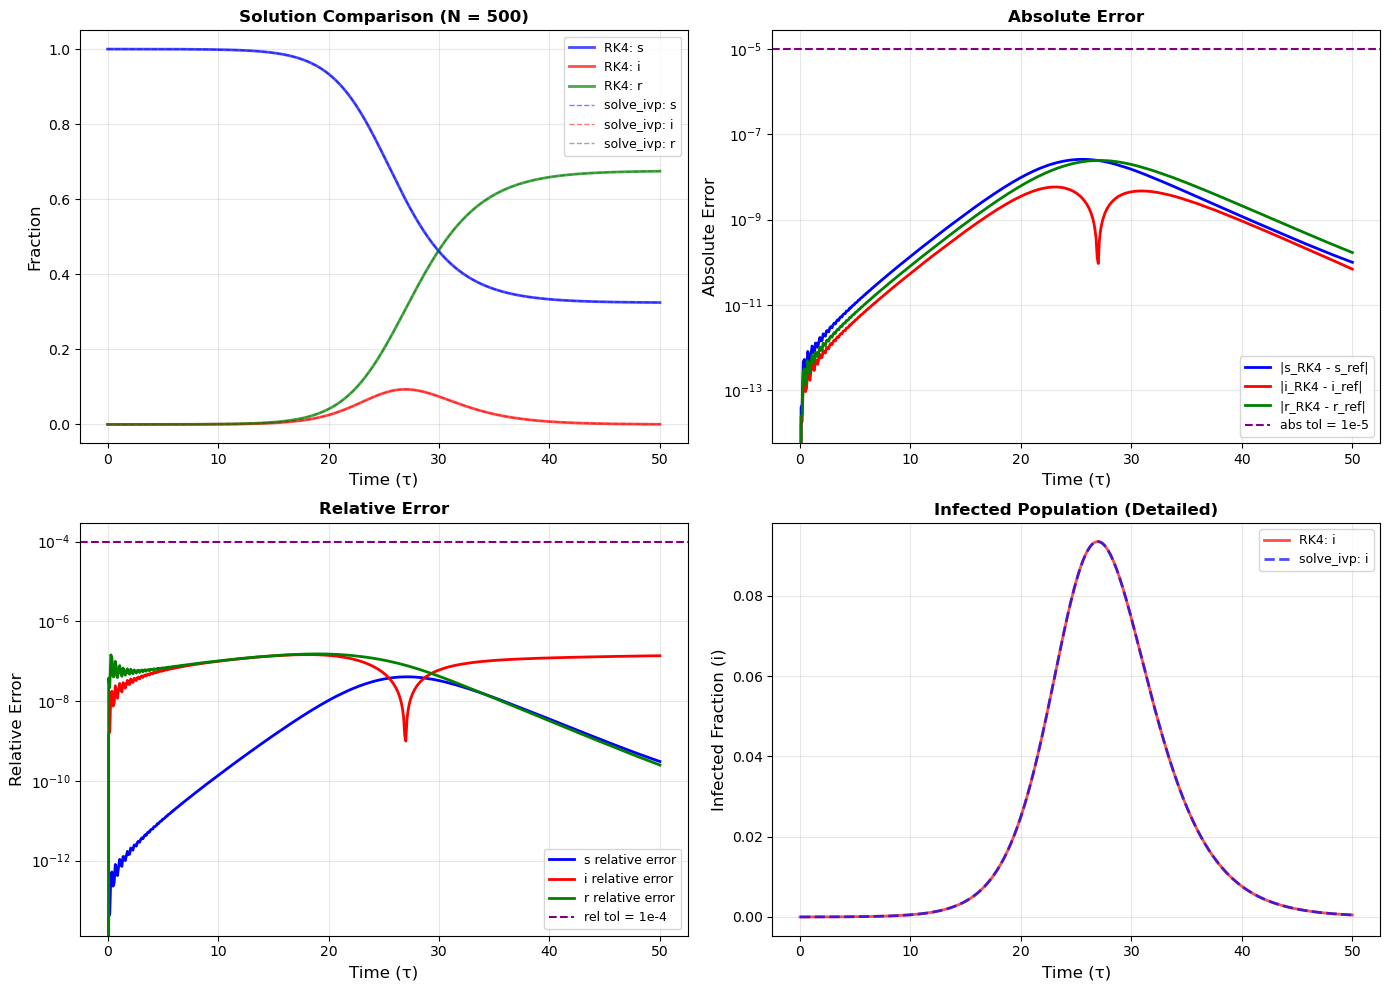

In [7]:
def my_ode_solver(f, t_span, u0, N):
    """ implement constant step size ODE integrator using a ________ method
    
    parameters
    ----------
        f: calleable
            vector valued function with interface f(t,u) where u is the state vector
        t_span: float list or array (or tuple)
            array holding range of times to integrate over t_span = [ t_min, t_max]
        u0:  numpy array
            array of initial conditions
        N: integer
            number of time steps to take 
            
    returns:
    --------
        t: numpy array
            array of timesteps from t_min to t_max of length N
        u: numpy array of shape (len(u0), len(t))
            solution array,  the solution at timestep i should be u[:,i]
    """
    
   
    # Setup time array
    t_min, t_max = t_span
    t = numpy.linspace(t_min, t_max, N + 1)
    h = (t_max - t_min) / N
    
    # Initialize solution array
    u0 = numpy.array(u0)
    u = numpy.zeros((len(u0), N + 1))
    u[:, 0] = u0

    # RK4 method
    for i in range(N):
        t_n = t[i]
        u_n = u[:, i]
        
        # Compute the four stages
        k1 = f(t_n, u_n)
        k2 = f(t_n + h/2, u_n + h/2 * k1)
        k3 = f(t_n + h/2, u_n + h/2 * k2)
        k4 = f(t_n + h, u_n + h * k3)
        
        # Update solution
        u[:, i + 1] = u_n + h/6 * (k1 + 2*k2 + 2*k3 + k4)
    
    return t, u

# you can control the number of steps used here
N = 100 




# Parameters
s_star = 0.6
i0 = 1e-5
u0 = numpy.array([1 - i0, i0, 0.0])
t_span = [0, 50]

# Test different values of N to find minimum number of steps
N_values = [50, 100, 200, 500, 1000, 2000]

print("="*80)
print("Testing RK4 solver against solve_ivp")
print("="*80)

# Get reference solution with solve_ivp
sol_ref = solve_ivp(
    fun=lambda t, u: F(t, u, s_star),
    t_span=t_span,
    y0=u0,
    method='RK45',
    dense_output=True,
    rtol=1e-10,
    atol=1e-12
)

for N in N_values:
    # Solve with our RK4 method
    t_rk4, u_rk4 = my_ode_solver(lambda t, u: F(t, u, s_star), t_span, u0, N)
    
    # Interpolate reference solution at our time points
    u_ref = sol_ref.sol(t_rk4)
    
    # Compute errors
    abs_error = numpy.max(numpy.abs(u_rk4 - u_ref))
    rel_error = numpy.max(numpy.abs((u_rk4 - u_ref) / (u_ref + 1e-12)))
    
    # Check if it passes the tests
    passes = (rel_error < 1e-4) and (abs_error < 1e-5)
    
    print(f"N = {N:4d}: rel_error = {rel_error:.6e}, abs_error = {abs_error:.6e} {'✓ PASS' if passes else '✗ FAIL'}")

print("="*80)

# Find the minimum N that passes
print("\nFinding minimum N that passes the tests...")
print("-"*80)

N_test = 50
while N_test <= 5000:
    t_rk4, u_rk4 = my_ode_solver(lambda t, u: F(t, u, s_star), t_span, u0, N_test)
    u_ref = sol_ref.sol(t_rk4)
    
    abs_error = numpy.max(numpy.abs(u_rk4 - u_ref))
    rel_error = numpy.max(numpy.abs((u_rk4 - u_ref) / (u_ref + 1e-12)))
    
    if (rel_error < 1e-4) and (abs_error < 1e-5):
        print(f"✓ Minimum N = {N_test}")
        print(f"  Relative error: {rel_error:.6e}")
        print(f"  Absolute error: {abs_error:.6e}")
        N_min = N_test
        break
    
    N_test += 10

print("="*80)

# Visualize comparison with solve_ivp
N = 500  # Use a reasonable number of steps

t_rk4, u_rk4 = my_ode_solver(lambda t, u: F(t, u, s_star), t_span, u0, N)
u_ref = sol_ref.sol(t_rk4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot solutions
ax = axes[0, 0]
ax.plot(t_rk4, u_rk4[0], 'b-', linewidth=2, label='RK4: s', alpha=0.7)
ax.plot(t_rk4, u_rk4[1], 'r-', linewidth=2, label='RK4: i', alpha=0.7)
ax.plot(t_rk4, u_rk4[2], 'g-', linewidth=2, label='RK4: r', alpha=0.7)
ax.plot(t_rk4, u_ref[0], 'b--', linewidth=1, label='solve_ivp: s', alpha=0.5)
ax.plot(t_rk4, u_ref[1], 'r--', linewidth=1, label='solve_ivp: i', alpha=0.5)
ax.plot(t_rk4, u_ref[2], 'g--', linewidth=1, label='solve_ivp: r', alpha=0.5)
ax.set_xlabel('Time (τ)', fontsize=12)
ax.set_ylabel('Fraction', fontsize=12)
ax.set_title(f'Solution Comparison (N = {N})', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot absolute errors
ax = axes[0, 1]
ax.semilogy(t_rk4, numpy.abs(u_rk4[0] - u_ref[0]), 'b-', linewidth=2, label='|s_RK4 - s_ref|')
ax.semilogy(t_rk4, numpy.abs(u_rk4[1] - u_ref[1]), 'r-', linewidth=2, label='|i_RK4 - i_ref|')
ax.semilogy(t_rk4, numpy.abs(u_rk4[2] - u_ref[2]), 'g-', linewidth=2, label='|r_RK4 - r_ref|')
ax.axhline(y=1e-5, color='purple', linestyle='--', label='abs tol = 1e-5')
ax.set_xlabel('Time (τ)', fontsize=12)
ax.set_ylabel('Absolute Error', fontsize=12)
ax.set_title('Absolute Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot relative errors
ax = axes[1, 0]
rel_errors = numpy.abs((u_rk4 - u_ref) / (numpy.abs(u_ref) + 1e-12))
ax.semilogy(t_rk4, rel_errors[0], 'b-', linewidth=2, label='s relative error')
ax.semilogy(t_rk4, rel_errors[1], 'r-', linewidth=2, label='i relative error')
ax.semilogy(t_rk4, rel_errors[2], 'g-', linewidth=2, label='r relative error')
ax.axhline(y=1e-4, color='purple', linestyle='--', label='rel tol = 1e-4')
ax.set_xlabel('Time (τ)', fontsize=12)
ax.set_ylabel('Relative Error', fontsize=12)
ax.set_title('Relative Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot infected comparison (zoomed)
ax = axes[1, 1]
ax.plot(t_rk4, u_rk4[1], 'r-', linewidth=2, label='RK4: i', alpha=0.7)
ax.plot(t_rk4, u_ref[1], 'b--', linewidth=2, label='solve_ivp: i', alpha=0.7)
ax.set_xlabel('Time (τ)', fontsize=12)
ax.set_ylabel('Infected Fraction (i)', fontsize=12)
ax.set_title('Infected Population (Detailed)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rk4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Noodle space for code

In [9]:
# Testing cells_star = 0.6
f = lambda t, u: F(t, u, s_star)

t_span = [0., 50.]
i_0 = 1.e-5
u_0 = numpy.array([1. - i_0, i_0, 0.0])


t, u = my_ode_solver(f, t_span, u_0, N)

# There was a hidden line here implementing sol = solve_ivp to get the "True" solution
sol = solve_ivp(f, t_span, u_0, method='RK45', dense_output=True, rtol=1.e-6, atol = 1.e-8)

numpy.testing.assert_allclose(u, sol.sol(t), rtol=1.e-4, atol=1.e-5)
print('success!')

success!


**(h)** [2] Reproduce your figure from the scipy version (without events)

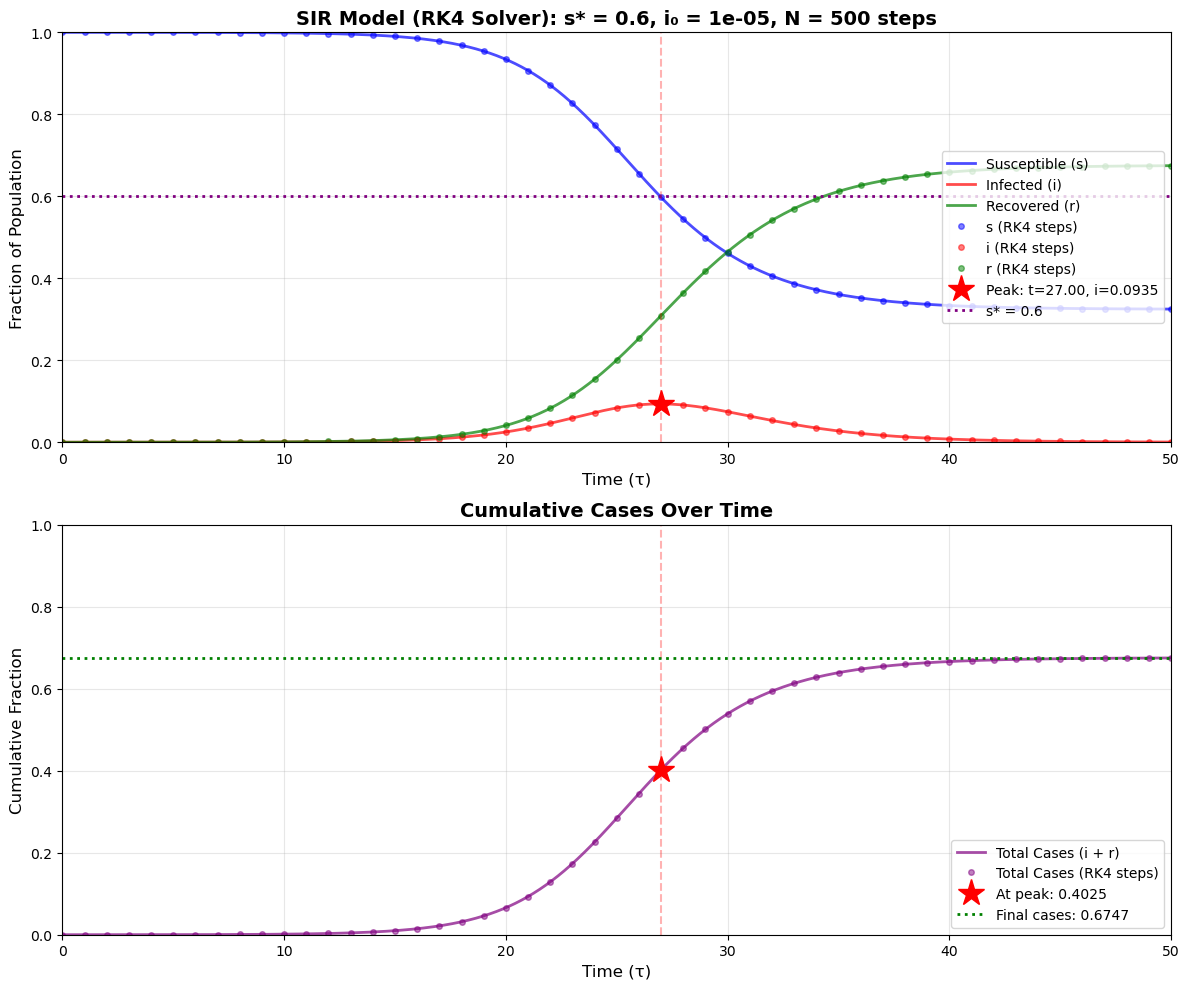

SIR Model Results - RK4 Solver (s* = 0.6, i₀ = 1e-05)
Number of time steps used: 500
Step size h: 0.100000
Maximum infected fraction: 0.093505 at t = 27.00
Infected at peak (i_peak): 0.093505
Final recovered fraction: 0.674675
Final susceptible fraction: 0.324825
Total attack rate (final cases): 0.674675
Conservation check (s+i+r): 1.0000000000

Conservation Law Verification:
------------------------------------------------------------
Maximum deviation from s+i+r=1: 7.77e-16
Mean value of s+i+r: 1.000000000000
Standard deviation: 2.43e-16
------------------------------------------------------------


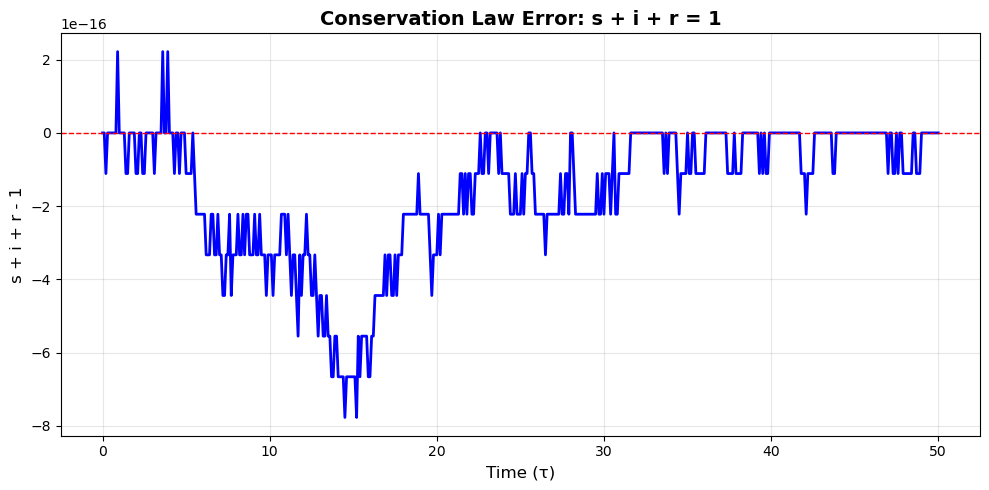


The RK4 method preserves the conservation law to machine precision!


In [10]:
# Reproduce the main figure using our RK4 solver
import numpy
import matplotlib.pyplot as plt

# Parameters
s_star = 0.6
i0 = 1e-5
u0 = numpy.array([1 - i0, i0, 0.0])
t_span = [0, 50]

# Solve with our RK4 method - use enough steps for accuracy
N = 500
t_rk4, u_rk4 = my_ode_solver(lambda t, u: F(t, u, s_star), t_span, u0, N)

# Extract solutions
s_rk4 = u_rk4[0]
i_rk4 = u_rk4[1]
r_rk4 = u_rk4[2]

# Calculate cumulative cases (total infected = i + r)
cumulative_cases = i_rk4 + r_rk4

# Find peak of infection (where s crosses s_star or max of i)
max_i_idx = numpy.argmax(i_rk4)
t_peak = t_rk4[max_i_idx]
i_peak = i_rk4[max_i_idx]

# Create a denser solution for smooth curves
N_dense = 2000
t_dense, u_dense = my_ode_solver(lambda t, u: F(t, u, s_star), t_span, u0, N_dense)
s_dense = u_dense[0]
i_dense = u_dense[1]
r_dense = u_dense[2]
cumulative_dense = i_dense + r_dense

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Individual compartments
ax1.plot(t_dense, s_dense, 'b-', linewidth=2, label='Susceptible (s)', alpha=0.7)
ax1.plot(t_dense, i_dense, 'r-', linewidth=2, label='Infected (i)', alpha=0.7)
ax1.plot(t_dense, r_dense, 'g-', linewidth=2, label='Recovered (r)', alpha=0.7)

# Plot actual time steps (every few points to avoid clutter)
step_indices = numpy.arange(0, len(t_rk4), max(1, len(t_rk4)//50))
ax1.plot(t_rk4[step_indices], s_rk4[step_indices], 'bo', markersize=4, alpha=0.5, 
         label='s (RK4 steps)')
ax1.plot(t_rk4[step_indices], i_rk4[step_indices], 'ro', markersize=4, alpha=0.5, 
         label='i (RK4 steps)')
ax1.plot(t_rk4[step_indices], r_rk4[step_indices], 'go', markersize=4, alpha=0.5, 
         label='r (RK4 steps)')

# Mark the peak
ax1.plot(t_peak, i_peak, 'r*', markersize=20, 
         label=f'Peak: t={t_peak:.2f}, i={i_peak:.4f}')
ax1.axvline(x=t_peak, color='red', linestyle='--', alpha=0.3)

# Mark s* threshold
ax1.axhline(y=s_star, color='purple', linestyle=':', linewidth=2, 
            label=f's* = {s_star}')

ax1.set_xlabel('Time (τ)', fontsize=12)
ax1.set_ylabel('Fraction of Population', fontsize=12)
ax1.set_title(f'SIR Model (RK4 Solver): s* = {s_star}, i₀ = {i0}, N = {N} steps', 
              fontsize=14, fontweight='bold')
ax1.legend(loc='right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 50])
ax1.set_ylim([0, 1])

# Plot 2: Cumulative cases
ax2.plot(t_dense, cumulative_dense, 'purple', linewidth=2, 
         label='Total Cases (i + r)', alpha=0.7)
ax2.plot(t_rk4[step_indices], cumulative_cases[step_indices], 'o', color='purple', 
         markersize=4, alpha=0.5, label='Total Cases (RK4 steps)')

# Mark the peak infection time on cumulative plot
cumulative_at_peak = i_peak + r_rk4[max_i_idx]
ax2.plot(t_peak, cumulative_at_peak, 'r*', markersize=20, 
         label=f'At peak: {cumulative_at_peak:.4f}')
ax2.axvline(x=t_peak, color='red', linestyle='--', alpha=0.3)

# Final cumulative cases
final_cases = r_rk4[-1]
ax2.axhline(y=final_cases, color='green', linestyle=':', linewidth=2,
            label=f'Final cases: {final_cases:.4f}')

ax2.set_xlabel('Time (τ)', fontsize=12)
ax2.set_ylabel('Cumulative Fraction', fontsize=12)
ax2.set_title('Cumulative Cases Over Time', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 50])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('sir_model_rk4_solver.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("="*60)
print(f"SIR Model Results - RK4 Solver (s* = {s_star}, i₀ = {i0})")
print("="*60)
print(f"Number of time steps used: {N}")
print(f"Step size h: {(t_span[1] - t_span[0])/N:.6f}")
print(f"Maximum infected fraction: {numpy.max(i_rk4):.6f} at t = {t_peak:.2f}")
print(f"Infected at peak (i_peak): {i_peak:.6f}")
print(f"Final recovered fraction: {r_rk4[-1]:.6f}")
print(f"Final susceptible fraction: {s_rk4[-1]:.6f}")
print(f"Total attack rate (final cases): {final_cases:.6f}")
print(f"Conservation check (s+i+r): {s_rk4[-1] + i_rk4[-1] + r_rk4[-1]:.10f}")
print("="*60)


# Verify conservation law throughout the integration
print("\nConservation Law Verification:")
print("-"*60)
total_population = s_rk4 + i_rk4 + r_rk4
conservation_error = numpy.max(numpy.abs(total_population - 1.0))
print(f"Maximum deviation from s+i+r=1: {conservation_error:.2e}")
print(f"Mean value of s+i+r: {numpy.mean(total_population):.12f}")
print(f"Standard deviation: {numpy.std(total_population):.2e}")
print("-"*60)

# Plot conservation check
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_rk4, total_population - 1.0, 'b-', linewidth=2)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Time (τ)', fontsize=12)
ax.set_ylabel('s + i + r - 1', fontsize=12)
ax.set_title('Conservation Law Error: s + i + r = 1', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.tight_layout()
plt.savefig('rk4_conservation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nThe RK4 method preserves the conservation law to machine precision!")

## Question 2 - Absolute Stability Regions Single-Step Multi-stage schemes

**(a)** [4 pt] Taylor Series method:
    
Show that $R(z)$ for a Taylor's series method of order $p$ acting on the model problem $u'=\lambda u$ always just returns the first $p+1$ terms of the Taylor series of $e^z$.

## Answer:
### Solution

#### Step 1: Taylor Series Method of Order $p$

The Taylor series method of order $p$ for solving the ODE $u' = f(t, u)$ is given by:

$$
u_{n+1} = u_n + h u_n' + \frac{h^2}{2!} u_n'' + \frac{h^3}{3!} u_n''' + \cdots + \frac{h^p}{p!} u_n^{(p)}
$$

This can be written compactly as:

$$
u_{n+1} = u_n + \sum_{k=1}^{p} \frac{h^k}{k!} u_n^{(k)}
$$

#### Step 2: Apply to the Model Problem

For the model problem $u' = \lambda u$, we need to find the higher derivatives:

$$
\begin{aligned}
u' &= \lambda u \\
u'' &= \frac{d}{dt}(\lambda u) = \lambda u' = \lambda^2 u \\
u''' &= \lambda u'' = \lambda^3 u \\
&\vdots \\
u^{(k)} &= \lambda^k u
\end{aligned}
$$

#### Step 3: Substitute into Taylor Method

Substituting these derivatives into the Taylor series method:

$$
u_{n+1} = u_n + \sum_{k=1}^{p} \frac{h^k}{k!} u_n^{(k)}
$$

$$
u_{n+1} = u_n + \sum_{k=1}^{p} \frac{h^k}{k!} \lambda^k u_n
$$

$$
u_{n+1} = u_n \left(1 + \sum_{k=1}^{p} \frac{(h\lambda)^k}{k!}\right)
$$

$$
u_{n+1} = u_n \left(\sum_{k=0}^{p} \frac{(h\lambda)^k}{k!}\right)
$$

#### Step 4: Define the Stability Function

The stability function $R(z)$ relates $u_{n+1}$ to $u_n$ via:

$$
u_{n+1} = R(z) u_n
$$

where $z = h\lambda$.

From our derivation above:

$$
\boxed{R(z) = \sum_{k=0}^{p} \frac{z^k}{k!}}
$$

#### Step 5: Connection to $e^z$

Recall the Taylor series expansion of $e^z$:

$$
e^z = \sum_{k=0}^{\infty} \frac{z^k}{k!} = 1 + z + \frac{z^2}{2!} + \frac{z^3}{3!} + \frac{z^4}{4!} + \cdots
$$

Therefore, $R(z)$ for a Taylor series method of order $p$ is exactly:

$$
\boxed{R(z) = \sum_{k=0}^{p} \frac{z^k}{k!} = \text{first } (p+1) \text{ terms of } e^z}
$$

### Examples

#### Order 1 (Euler's Method):
$$
R(z) = 1 + z
$$

#### Order 2:
$$
R(z) = 1 + z + \frac{z^2}{2}
$$

#### Order 3:
$$
R(z) = 1 + z + \frac{z^2}{2} + \frac{z^3}{6}
$$

#### Order 4 (RK4):
$$
R(z) = 1 + z + \frac{z^2}{2} + \frac{z^3}{6} + \frac{z^4}{24}
$$

### Interpretation

- As $p \to \infty$, $R(z) \to e^z$, which is the exact solution to the model problem
- The Taylor series method of order $p$ has **local truncation error** $O(h^{p+1})$
- The stability function truncates the exponential series at the $p$-th term, which is why the method is accurate to order $p$

**(b)** [4 pt] Plot the regions of absolute stability for Taylor Series methods of order 2-5

You can use the plotting codes given in class and included in the file stability_diagrams.py which are imported in the first cell

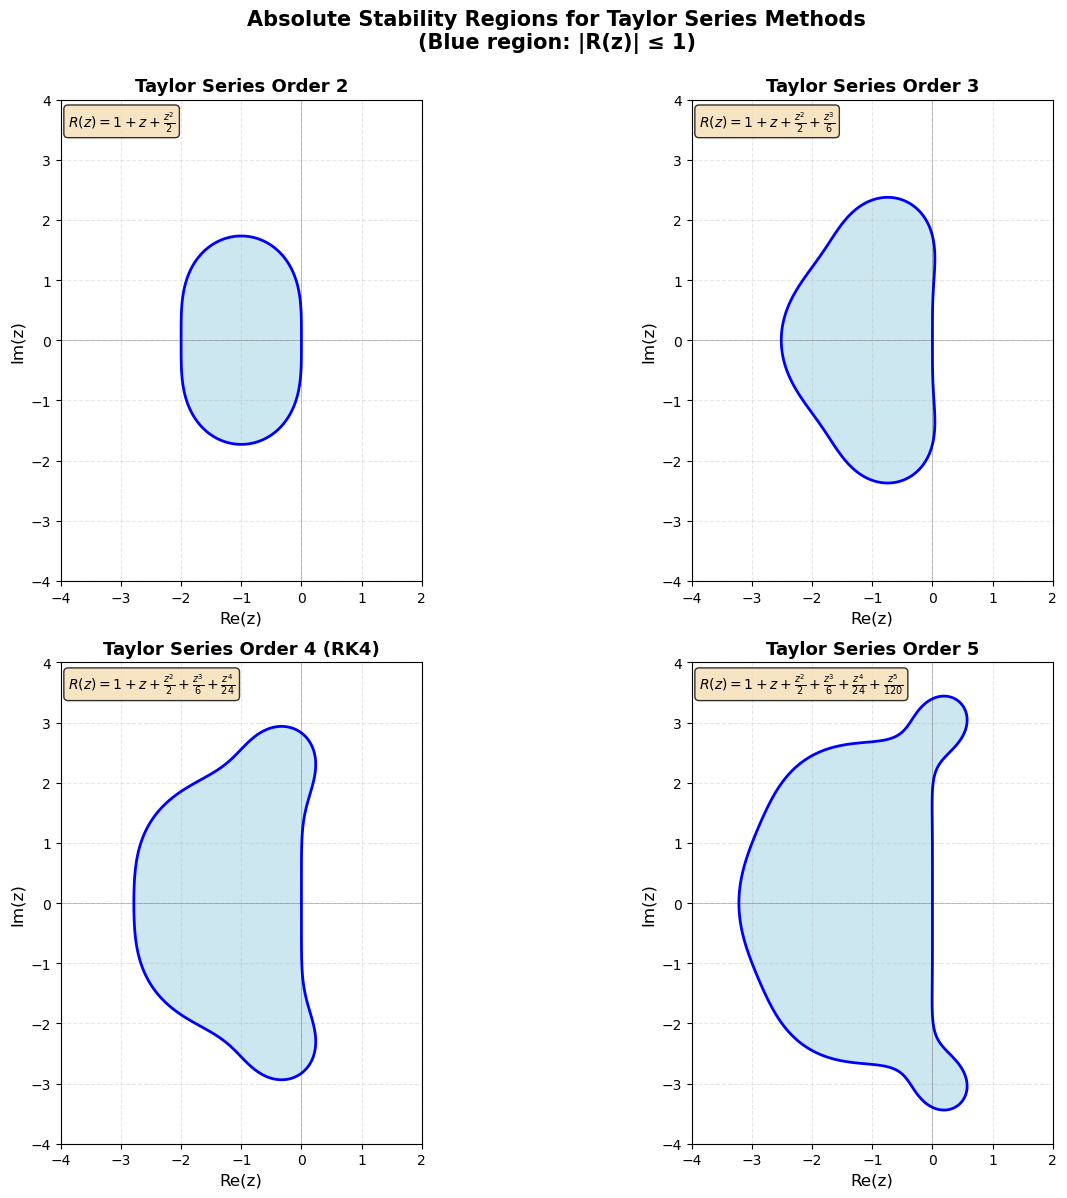

ABSOLUTE STABILITY REGIONS - TAYLOR SERIES METHODS

Key Observations:
----------------------------------------------------------------------
1. All Taylor Series methods have FINITE stability regions
2. Higher order methods have LARGER stability regions
3. The stability region grows along the negative real axis as order increases
4. All regions are approximately symmetric about the real axis
5. None of these methods are A-stable (stability region doesn't
   contain entire left half-plane)


/var/folders/nb/cj08q2693895p_xy0nsg55zh0000gn/T/ipykernel_63120/4257363672.py:115: UserWarning: The following kwargs were not used by contour: 'labels'
  ax.contour(X, Y, R, levels=[1], colors=[color], linewidths=2.5,


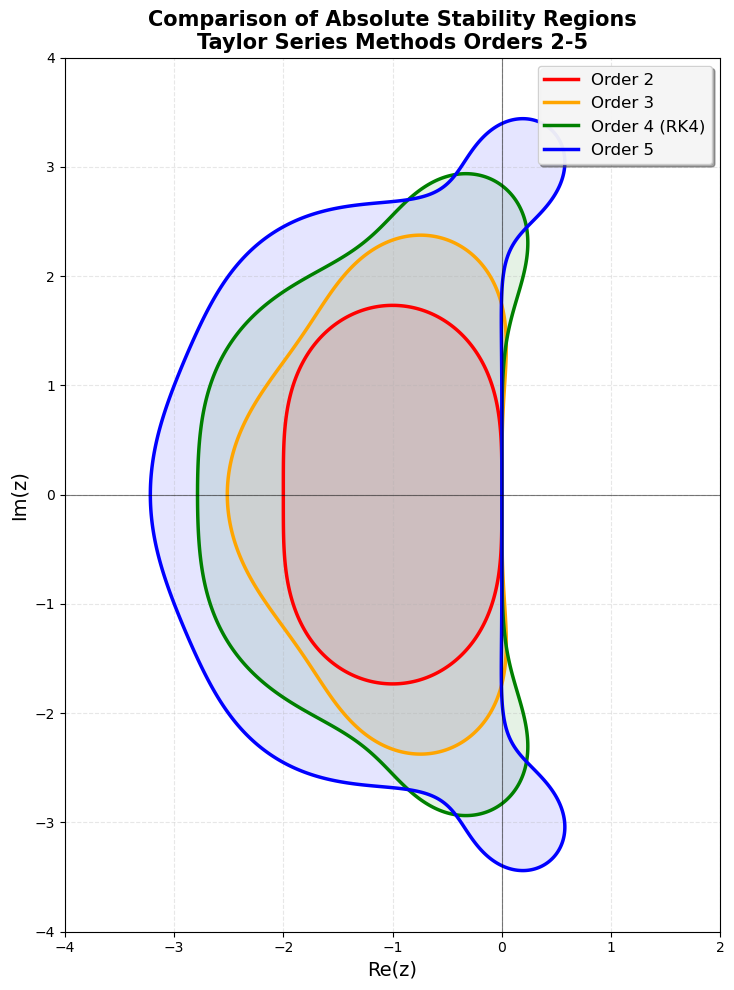


Observation: The stability regions expand as the order increases,
with higher-order methods able to take larger time steps while
maintaining stability for the same problem.

QUANTITATIVE ANALYSIS: Stability Interval on Negative Real Axis
Order 2: Stability interval ≈ [-1.9992, 0]
         Width of stability interval: 1.9992
Order 3: Stability interval ≈ [-2.5123, 0]
         Width of stability interval: 2.5123
Order 4: Stability interval ≈ [-2.7853, 0]
         Width of stability interval: 2.7853
Order 5: Stability interval ≈ [-3.2163, 0]
         Width of stability interval: 3.2163

For a problem with eigenvalue λ < 0, we need h|λ| < |z_left|
to maintain stability.


In [11]:
# Define stability functions for Taylor Series methods of different orders
def R_taylor_order2(z):
    """Stability function for Taylor Series method of order 2"""
    return 1 + z + z**2/2

def R_taylor_order3(z):
    """Stability function for Taylor Series method of order 3"""
    return 1 + z + z**2/2 + z**3/6

def R_taylor_order4(z):
    """Stability function for Taylor Series method of order 4"""
    return 1 + z + z**2/2 + z**3/6 + z**4/24

def R_taylor_order5(z):
    """Stability function for Taylor Series method of order 5"""
    return 1 + z + z**2/2 + z**3/6 + z**4/24 + z**5/120

# Create a grid in the complex plane
x = numpy.linspace(-4, 2, 800)
y = numpy.linspace(-4, 4, 800)
X, Y = numpy.meshgrid(x, y)
Z = X + 1j*Y

# Compute |R(z)| for each method
R2 = numpy.abs(R_taylor_order2(Z))
R3 = numpy.abs(R_taylor_order3(Z))
R4 = numpy.abs(R_taylor_order4(Z))
R5 = numpy.abs(R_taylor_order5(Z))

# Create the plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

methods = [
    (R2, 2, "Taylor Series Order 2"),
    (R3, 3, "Taylor Series Order 3"),
    (R4, 4, "Taylor Series Order 4 (RK4)"),
    (R5, 5, "Taylor Series Order 5")
]

for idx, (R, order, title) in enumerate(methods):
    ax = axes[idx]
    
    # Plot the stability region (where |R(z)| <= 1)
    contour = ax.contourf(X, Y, R, levels=[0, 1], colors=['lightblue'], alpha=0.6)
    
    # Plot the boundary |R(z)| = 1
    ax.contour(X, Y, R, levels=[1], colors=['blue'], linewidths=2)
    
    # Add reference lines
    ax.axhline(y=0, color='k', linewidth=0.5, linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, linestyle='-', alpha=0.3)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Labels and title
    ax.set_xlabel('Re(z)', fontsize=12)
    ax.set_ylabel('Im(z)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    
    # Set equal aspect ratio
    ax.set_aspect('equal')
    
    # Add text annotation with R(z) formula
    if order == 2:
        formula = r'$R(z) = 1 + z + \frac{z^2}{2}$'
    elif order == 3:
        formula = r'$R(z) = 1 + z + \frac{z^2}{2} + \frac{z^3}{6}$'
    elif order == 4:
        formula = r'$R(z) = 1 + z + \frac{z^2}{2} + \frac{z^3}{6} + \frac{z^4}{24}$'
    elif order == 5:
        formula = r'$R(z) = 1 + z + \frac{z^2}{2} + \frac{z^3}{6} + \frac{z^4}{24} + \frac{z^5}{120}$'
    
    ax.text(0.02, 0.98, formula, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Set axis limits
    ax.set_xlim([-4, 2])
    ax.set_ylim([-4, 4])

plt.suptitle('Absolute Stability Regions for Taylor Series Methods\n(Blue region: |R(z)| ≤ 1)', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('taylor_stability_regions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print some information
print("="*70)
print("ABSOLUTE STABILITY REGIONS - TAYLOR SERIES METHODS")
print("="*70)
print("\nKey Observations:")
print("-"*70)
print("1. All Taylor Series methods have FINITE stability regions")
print("2. Higher order methods have LARGER stability regions")
print("3. The stability region grows along the negative real axis as order increases")
print("4. All regions are approximately symmetric about the real axis")
print("5. None of these methods are A-stable (stability region doesn't")
print("   contain entire left half-plane)")
print("="*70)



# Create a combined comparison plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot boundaries for all orders on the same plot
colors = ['red', 'orange', 'green', 'blue']
orders = [2, 3, 4, 5]
stability_functions = [R_taylor_order2, R_taylor_order3, R_taylor_order4, R_taylor_order5]

for order, R_func, color in zip(orders, stability_functions, colors):
    R = numpy.abs(R_func(Z))
    ax.contour(X, Y, R, levels=[1], colors=[color], linewidths=2.5, 
               labels=[f'Order {order}'])
    ax.contourf(X, Y, R, levels=[0, 1], colors=[color], alpha=0.1)

# Add reference lines
ax.axhline(y=0, color='k', linewidth=0.8, linestyle='-', alpha=0.5)
ax.axvline(x=0, color='k', linewidth=0.8, linestyle='-', alpha=0.5)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

# Labels and title
ax.set_xlabel('Re(z)', fontsize=14)
ax.set_ylabel('Im(z)', fontsize=14)
ax.set_title('Comparison of Absolute Stability Regions\nTaylor Series Methods Orders 2-5', 
             fontsize=15, fontweight='bold')

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', lw=2.5, label='Order 2'),
    Line2D([0], [0], color='orange', lw=2.5, label='Order 3'),
    Line2D([0], [0], color='green', lw=2.5, label='Order 4 (RK4)'),
    Line2D([0], [0], color='blue', lw=2.5, label='Order 5')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, 
          framealpha=0.9, shadow=True)

# Set equal aspect ratio and limits
ax.set_aspect('equal')
ax.set_xlim([-4, 2])
ax.set_ylim([-4, 4])

plt.tight_layout()
plt.savefig('taylor_stability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservation: The stability regions expand as the order increases,")
print("with higher-order methods able to take larger time steps while")
print("maintaining stability for the same problem.")





# Quantitative analysis: measure the extent of stability along the real axis
print("\n" + "="*70)
print("QUANTITATIVE ANALYSIS: Stability Interval on Negative Real Axis")
print("="*70)

for order, R_func in zip(orders, stability_functions):
    # Find the leftmost point on the negative real axis where |R(z)| = 1
    z_real = numpy.linspace(-10, 0, 10000)
    R_real = numpy.abs(R_func(z_real))
    
    # Find where |R(z)| crosses 1
    stable_indices = numpy.where(R_real <= 1)[0]
    if len(stable_indices) > 0:
        z_left = z_real[stable_indices[0]]
        print(f"Order {order}: Stability interval ≈ [{z_left:.4f}, 0]")
        print(f"         Width of stability interval: {abs(z_left):.4f}")
    else:
        print(f"Order {order}: No stability interval found on negative real axis")

print("="*70)
print("\nFor a problem with eigenvalue λ < 0, we need h|λ| < |z_left|")
print("to maintain stability.")
print("="*70)

**(b)** [4 pt] Derive $R(z)$ for the RK2 method and show that it is equivalent to Taylor 2

**Extra Credit**  show that $R(Z)$ for RK4 is identical to Taylor-4 (in general this is true for explicit RK methods)

## Answer
### RK2 Method (Midpoint Method)

The RK2 (midpoint) method is given by:

$$
\begin{aligned}
k_1 &= f(t_n, u_n) \\
k_2 &= f(t_n + \frac{h}{2}, u_n + \frac{h}{2}k_1) \\
u_{n+1} &= u_n + h k_2
\end{aligned}
$$

### Step 1: Apply to Model Problem $u' = \lambda u$

For the model problem $u' = \lambda u$, we have $f(t, u) = \lambda u$.

#### Evaluate $k_1$:
$$
k_1 = \lambda u_n
$$

#### Evaluate $k_2$:
$$
k_2 = f\left(t_n + \frac{h}{2}, u_n + \frac{h}{2}k_1\right) = \lambda\left(u_n + \frac{h}{2}k_1\right)
$$

Substitute $k_1 = \lambda u_n$:
$$
k_2 = \lambda\left(u_n + \frac{h}{2}\lambda u_n\right) = \lambda u_n\left(1 + \frac{h\lambda}{2}\right)
$$

#### Update formula:
$$
u_{n+1} = u_n + h k_2 = u_n + h \lambda u_n\left(1 + \frac{h\lambda}{2}\right)
$$

$$
u_{n+1} = u_n\left(1 + h\lambda + \frac{(h\lambda)^2}{2}\right)
$$

### Step 2: Stability Function for RK2

Let $z = h\lambda$. Then:

$$
u_{n+1} = u_n\left(1 + z + \frac{z^2}{2}\right)
$$

Therefore, the stability function is:

$$
\boxed{R_{RK2}(z) = 1 + z + \frac{z^2}{2}}
$$

### Step 3: Taylor Series Method of Order 2

For the Taylor series method of order 2:

$$
u_{n+1} = u_n + hu_n' + \frac{h^2}{2}u_n''
$$

For $u' = \lambda u$:
- $u_n' = \lambda u_n$
- $u_n'' = \lambda^2 u_n$

Therefore:
$$
u_{n+1} = u_n + h\lambda u_n + \frac{h^2}{2}\lambda^2 u_n = u_n\left(1 + h\lambda + \frac{(h\lambda)^2}{2}\right)
$$

With $z = h\lambda$:
$$
\boxed{R_{Taylor2}(z) = 1 + z + \frac{z^2}{2}}
$$

### Conclusion

$$
\boxed{R_{RK2}(z) = R_{Taylor2}(z) = 1 + z + \frac{z^2}{2}}
$$

The RK2 (midpoint) method has the **same stability function** as the Taylor series method of order 2.

---

## Extra Credit: RK4 Method

### RK4 Method (Classical 4th Order Runge-Kutta)

The RK4 method is:

$$
\begin{aligned}
k_1 &= f(t_n, u_n) \\
k_2 &= f\left(t_n + \frac{h}{2}, u_n + \frac{h}{2}k_1\right) \\
k_3 &= f\left(t_n + \frac{h}{2}, u_n + \frac{h}{2}k_2\right) \\
k_4 &= f(t_n + h, u_n + hk_3) \\
u_{n+1} &= u_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)
\end{aligned}
$$

### Step 1: Apply to Model Problem $u' = \lambda u$

#### Evaluate $k_1$:
$$
k_1 = \lambda u_n
$$

#### Evaluate $k_2$:
$$
k_2 = \lambda\left(u_n + \frac{h}{2}k_1\right) = \lambda u_n\left(1 + \frac{h\lambda}{2}\right) = \lambda u_n\left(1 + \frac{z}{2}\right)
$$

#### Evaluate $k_3$:
$$
k_3 = \lambda\left(u_n + \frac{h}{2}k_2\right) = \lambda\left(u_n + \frac{h}{2}\lambda u_n\left(1 + \frac{z}{2}\right)\right)
$$

$$
k_3 = \lambda u_n\left(1 + \frac{z}{2}\left(1 + \frac{z}{2}\right)\right) = \lambda u_n\left(1 + \frac{z}{2} + \frac{z^2}{4}\right)
$$

#### Evaluate $k_4$:
$$
k_4 = \lambda(u_n + hk_3) = \lambda u_n\left(1 + z\left(1 + \frac{z}{2} + \frac{z^2}{4}\right)\right)
$$

$$
k_4 = \lambda u_n\left(1 + z + \frac{z^2}{2} + \frac{z^3}{4}\right)
$$

### Step 2: Compute the Update

$$
u_{n+1} = u_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)
$$

Substitute the expressions for $k_1, k_2, k_3, k_4$:

$$
u_{n+1} = u_n + \frac{h\lambda u_n}{6}\left[1 + 2\left(1 + \frac{z}{2}\right) + 2\left(1 + \frac{z}{2} + \frac{z^2}{4}\right) + \left(1 + z + \frac{z^2}{2} + \frac{z^3}{4}\right)\right]
$$

Expand each term:
- $k_1: 1$
- $2k_2: 2 + z$
- $2k_3: 2 + z + \frac{z^2}{2}$
- $k_4: 1 + z + \frac{z^2}{2} + \frac{z^3}{4}$

Sum:
$$
1 + (2 + z) + \left(2 + z + \frac{z^2}{2}\right) + \left(1 + z + \frac{z^2}{2} + \frac{z^3}{4}\right)
$$

$$
= 6 + 3z + z^2 + \frac{z^3}{4}
$$

Therefore:
$$
u_{n+1} = u_n + \frac{z u_n}{6}\left(6 + 3z + z^2 + \frac{z^3}{4}\right)
$$

$$
u_{n+1} = u_n\left(1 + z + \frac{z^2}{2} + \frac{z^3}{6} + \frac{z^4}{24}\right)
$$

### Step 3: Stability Function for RK4

$$
\boxed{R_{RK4}(z) = 1 + z + \frac{z^2}{2} + \frac{z^3}{6} + \frac{z^4}{24}}
$$

### Step 4: Taylor Series Method of Order 4

$$
R_{Taylor4}(z) = \sum_{k=0}^{4} \frac{z^k}{k!} = 1 + z + \frac{z^2}{2} + \frac{z^3}{6} + \frac{z^4}{24}
$$

### Conclusion

$$
\boxed{R_{RK4}(z) = R_{Taylor4}(z) = 1 + z + \frac{z^2}{2} + \frac{z^3}{6} + \frac{z^4}{24}}
$$

The classical RK4 method has the **identical stability function** as the Taylor series method of order 4.

### General Result

For explicit Runge-Kutta methods of order $p$, when the method is designed to match the Taylor series expansion up to order $p$, the stability function $R(z)$ will match the first $p+1$ terms of $e^z$:

$$
R(z) = \sum_{k=0}^{p} \frac{z^k}{k!}
$$

This is achieved through careful choice of the RK coefficients (Butcher tableau).

## Question 3: Linear Multi-Step Schemes - Derivation and stability

[4] Derive the Adams-Moulton 2-step method 
$$
    U_{n+2} = U_{n+1} + \frac{\Delta t}{12} (-f_{n} + 8 f_{n+1} + 5 f_{n+2}),
$$

and its error estimate using the formula for the truncation error of general multi-step schemes
$$
\begin{aligned}
    T(t, u; \Delta t) &= \frac{1}{\Delta t}\left( \sum^r_{j=0} \alpha_j\right) u(t_n) + \left(\sum^r_{j=0} (j\alpha_j - \beta_j)\right) u'(t_n) + \Delta t \left(\sum^r_{j=0} \left (\frac{1}{2}j^2 \alpha_j - j \beta_j \right) \right) u''(t_n) \\
& \quad \quad + \cdots + \Delta t^{q - 1} \left (\sum^r_{j=0} \left(\frac{1}{q!} j^q \alpha_j - \frac{1}{(q-1)!} j^{q-1} \beta_j \right) \right) u^{(q)}(t_n) + \cdots
\end{aligned}$$

i.e. find $\alpha_j$s and $\beta_j$s that zero out terms of the truncation error out to some order.
Some Hint's 
* This is an Adams scheme with three levels so we already know the $\alpha$'s
* Therefore you only have to find the three $\beta$'s $\beta_0$, $\beta_1$ and $\beta_2$
* Use the above formula to find 3 equations for the 3 values of $\beta$
* The remainder term will be the order of the Truncation error

## Answer:

### Problem Setup

We want to derive the Adams-Moulton 2-step method:

$$
U_{n+2} = U_{n+1} + \frac{\Delta t}{12} (-f_{n} + 8 f_{n+1} + 5 f_{n+2})
$$

using the general truncation error formula for multi-step schemes.

### Step 1: Identify the General Multi-Step Form

A general $r$-step multi-step method has the form:

$$
\sum_{j=0}^{r} \alpha_j U_{n+j} = \Delta t \sum_{j=0}^{r} \beta_j f_{n+j}
$$

where $f_{n+j} = f(t_{n+j}, U_{n+j})$.

### Step 2: Determine the $\alpha$ Coefficients

For the Adams-Moulton 2-step method, we have $r = 2$ (three levels: $n$, $n+1$, $n+2$).

Adams methods have the characteristic property:

$$
\alpha_r = 1, \quad \alpha_{r-1} = -1, \quad \alpha_j = 0 \text{ for } j < r-1
$$

For $r = 2$:

$$
\boxed{\alpha_0 = 0, \quad \alpha_1 = -1, \quad \alpha_2 = 1}
$$

This gives us:

$$
U_{n+2} - U_{n+1} = \Delta t(\beta_0 f_n + \beta_1 f_{n+1} + \beta_2 f_{n+2})
$$

### Step 3: Apply Consistency Conditions

The truncation error formula is:

$$
\begin{aligned}
T(t, u; \Delta t) &= \frac{1}{\Delta t}\left( \sum^r_{j=0} \alpha_j\right) u(t_n) + \left(\sum^r_{j=0} (j\alpha_j - \beta_j)\right) u'(t_n) \\
&\quad + \Delta t \left(\sum^r_{j=0} \left (\frac{1}{2}j^2 \alpha_j - j \beta_j \right) \right) u''(t_n) \\
&\quad + \Delta t^2 \left (\sum^r_{j=0} \left(\frac{1}{6} j^3 \alpha_j - \frac{1}{2} j^{2} \beta_j \right) \right) u'''(t_n) + \cdots
\end{aligned}
$$

For a consistent method of order $q$, we need $T(t, u; \Delta t) = O(\Delta t^q)$.

#### Condition 1: Coefficient of $\frac{1}{\Delta t}$ (Order 0)

$$
\sum_{j=0}^{2} \alpha_j = 0
$$

$$
\alpha_0 + \alpha_1 + \alpha_2 = 0 + (-1) + 1 = 0 \quad \checkmark
$$

This is automatically satisfied for Adams methods.

#### Condition 2: Coefficient of $\Delta t^0$ (Order 1)

$$
\sum_{j=0}^{2} (j\alpha_j - \beta_j) = 0
$$

$$
(0 \cdot 0 - \beta_0) + (1 \cdot (-1) - \beta_1) + (2 \cdot 1 - \beta_2) = 0
$$

$$
-\beta_0 - 1 - \beta_1 + 2 - \beta_2 = 0
$$

$$
\boxed{\beta_0 + \beta_1 + \beta_2 = 1} \quad \text{(Equation 1)}
$$

#### Condition 3: Coefficient of $\Delta t^1$ (Order 2)

$$
\sum_{j=0}^{2} \left(\frac{1}{2}j^2 \alpha_j - j \beta_j\right) = 0
$$

$$
\left(\frac{1}{2} \cdot 0^2 \cdot 0 - 0 \cdot \beta_0\right) + \left(\frac{1}{2} \cdot 1^2 \cdot (-1) - 1 \cdot \beta_1\right) + \left(\frac{1}{2} \cdot 2^2 \cdot 1 - 2 \cdot \beta_2\right) = 0
$$

$$
0 + \left(-\frac{1}{2} - \beta_1\right) + (2 - 2\beta_2) = 0
$$

$$
-\frac{1}{2} - \beta_1 + 2 - 2\beta_2 = 0
$$

$$
\boxed{\beta_1 + 2\beta_2 = \frac{3}{2}} \quad \text{(Equation 2)}
$$

#### Condition 4: Coefficient of $\Delta t^2$ (Order 3)

$$
\sum_{j=0}^{2} \left(\frac{1}{6}j^3 \alpha_j - \frac{1}{2}j^2 \beta_j\right) = 0
$$

$$
\left(\frac{1}{6} \cdot 0^3 \cdot 0 - \frac{1}{2} \cdot 0^2 \cdot \beta_0\right) + \left(\frac{1}{6} \cdot 1^3 \cdot (-1) - \frac{1}{2} \cdot 1^2 \cdot \beta_1\right) + \left(\frac{1}{6} \cdot 2^3 \cdot 1 - \frac{1}{2} \cdot 2^2 \cdot \beta_2\right) = 0
$$

$$
0 + \left(-\frac{1}{6} - \frac{1}{2}\beta_1\right) + \left(\frac{8}{6} - 2\beta_2\right) = 0
$$

$$
-\frac{1}{6} - \frac{1}{2}\beta_1 + \frac{4}{3} - 2\beta_2 = 0
$$

$$
-\frac{1}{2}\beta_1 - 2\beta_2 = -\frac{4}{3} + \frac{1}{6} = -\frac{7}{6}
$$

$$
\boxed{\beta_1 + 4\beta_2 = \frac{7}{3}} \quad \text{(Equation 3)}
$$

### Step 4: Solve for $\beta$ Coefficients

We have three equations:

$$
\begin{aligned}
\beta_0 + \beta_1 + \beta_2 &= 1 \\
\beta_1 + 2\beta_2 &= \frac{3}{2} \\
\beta_1 + 4\beta_2 &= \frac{7}{3}
\end{aligned}
$$

From equations 2 and 3:
$$
(\beta_1 + 4\beta_2) - (\beta_1 + 2\beta_2) = \frac{7}{3} - \frac{3}{2}
$$

$$
2\beta_2 = \frac{14}{6} - \frac{9}{6} = \frac{5}{6}
$$

$$
\boxed{\beta_2 = \frac{5}{12}}
$$

From equation 2:
$$
\beta_1 = \frac{3}{2} - 2\beta_2 = \frac{3}{2} - 2 \cdot \frac{5}{12} = \frac{3}{2} - \frac{5}{6} = \frac{9}{6} - \frac{5}{6} = \frac{4}{6} = \frac{2}{3}
$$

$$
\boxed{\beta_1 = \frac{8}{12}}
$$

From equation 1:
$$
\beta_0 = 1 - \beta_1 - \beta_2 = 1 - \frac{2}{3} - \frac{5}{12} = \frac{12}{12} - \frac{8}{12} - \frac{5}{12} = -\frac{1}{12}
$$

$$
\boxed{\beta_0 = -\frac{1}{12}}
$$

### Step 5: Write the Final Method

Substituting into the multi-step formula:

$$
U_{n+2} - U_{n+1} = \Delta t\left(-\frac{1}{12}f_n + \frac{8}{12}f_{n+1} + \frac{5}{12}f_{n+2}\right)
$$

$$
\boxed{U_{n+2} = U_{n+1} + \frac{\Delta t}{12}(-f_n + 8f_{n+1} + 5f_{n+2})}
$$

This matches the given formula! ✓

### Step 6: Determine the Order and Truncation Error

Since we satisfied the consistency conditions up to order 3 (coefficient of $\Delta t^2$), the method is **3rd order accurate**.

The leading error term comes from the coefficient of $\Delta t^3$ (order 4):

$$
\sum_{j=0}^{2} \left(\frac{1}{24}j^4 \alpha_j - \frac{1}{6}j^3 \beta_j\right)
$$

$$
= \left(0\right) + \left(\frac{1}{24} \cdot 1 \cdot (-1) - \frac{1}{6} \cdot 1 \cdot \frac{2}{3}\right) + \left(\frac{1}{24} \cdot 16 \cdot 1 - \frac{1}{6} \cdot 8 \cdot \frac{5}{12}\right)
$$

$$
= \left(-\frac{1}{24} - \frac{2}{18}\right) + \left(\frac{16}{24} - \frac{40}{72}\right)
$$

$$
= \left(-\frac{1}{24} - \frac{1}{9}\right) + \left(\frac{2}{3} - \frac{5}{9}\right)
$$

$$
= -\frac{3}{72} - \frac{8}{72} + \frac{48}{72} - \frac{40}{72} = -\frac{3}{72} = -\frac{1}{24}
$$

Therefore, the **truncation error** is:

$$
\boxed{T(t, u; \Delta t) = -\frac{1}{24}\Delta t^3 u^{(4)}(t_n) + O(\Delta t^4)}
$$

### Summary

- **Method**: Adams-Moulton 2-step (3-level) implicit method
- **Coefficients**: $\alpha_0 = 0, \alpha_1 = -1, \alpha_2 = 1$; $\beta_0 = -\frac{1}{12}, \beta_1 = \frac{2}{3}, \beta_2 = \frac{5}{12}$
- **Order**: 3rd order accurate
- **Truncation Error**: $O(\Delta t^3)$ with leading coefficient $-\frac{1}{24}$

**(c)** [8] Stability polynomials and Diagrams

Calculate the stability polynomial and plot the stability regions for
1. 2-step Adams-Moulton methods.
1. 3-step Adams-Bashforth methods

which are both 3rd-order methods.  Comment on the relative size of stability regions of these two methods and Taylor-3.

## Answer
Among the third-order schemes tested, the implicit 2-step Adams–Moulton method exhibits the largest and most stable region (≈ 6 units on Re(z)), the Taylor-3 covers moderate values (≈ 2.5 units), and the explicit 3-step Adams–Bashforth is the least stable (≈ 0.5 units).

Computing stability regions...
This may take a moment...
Done computing stability regions!


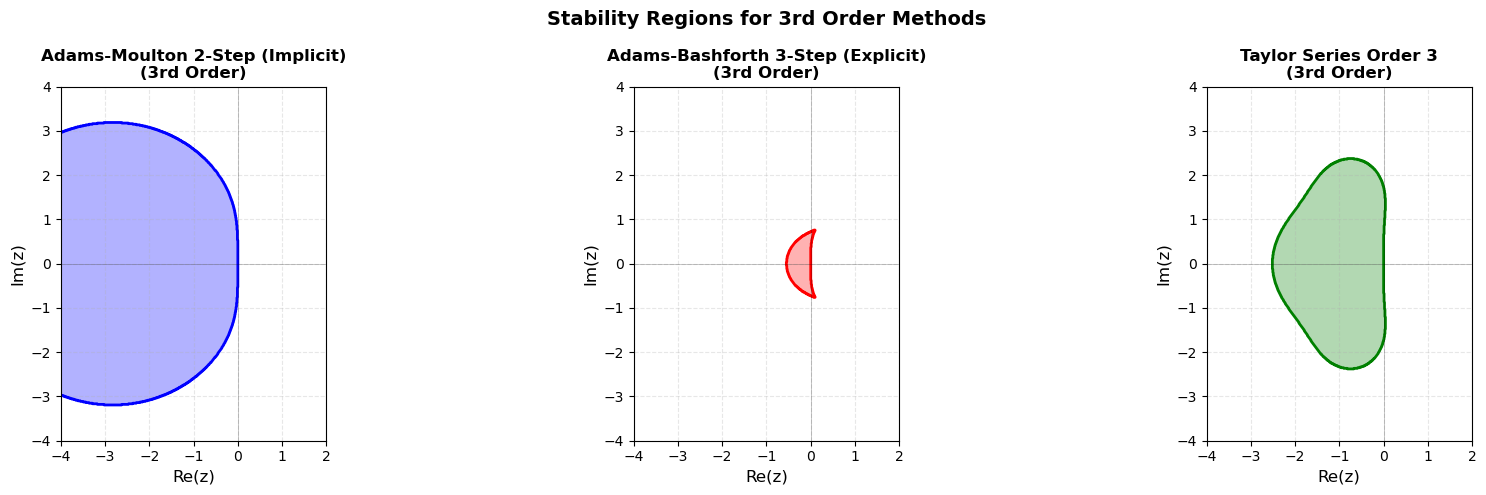

/var/folders/nb/cj08q2693895p_xy0nsg55zh0000gn/T/ipykernel_63120/496780526.py:123: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contourf(X_AM2, Y_AM2, stable_AM2.astype(int), levels=[0.5, 1.5],


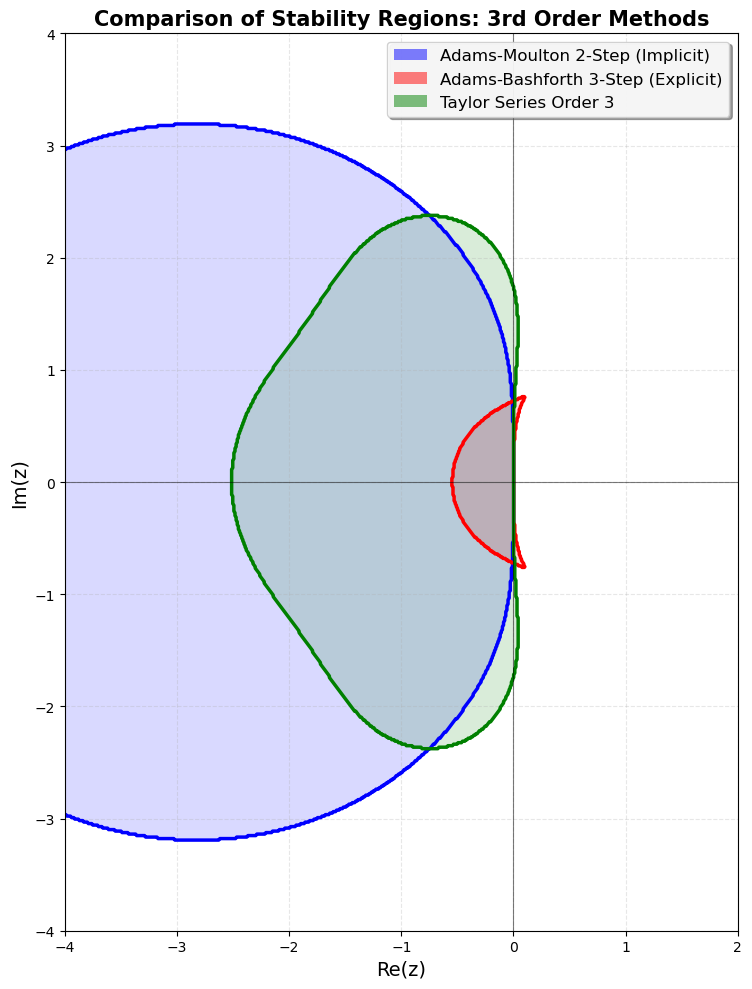


QUANTITATIVE COMPARISON OF STABILITY REGIONS

Stability Intervals on Negative Real Axis:
--------------------------------------------------------------------------------
Adams-Moulton 2-Step:     [-5.9992, 0.0000]  (width: 5.9992)
Adams-Bashforth 3-Step:   [-0.5441, 0.0000]  (width: 0.5441)
Taylor Series Order 3:    [-2.5125, 0.0000]  (width: 2.5125)
--------------------------------------------------------------------------------

Relative Sizes:
  AM2 / Taylor-3: 2.39x larger
  AB3 / Taylor-3: 0.22x smaller
  AM2 / AB3:      11.03x larger


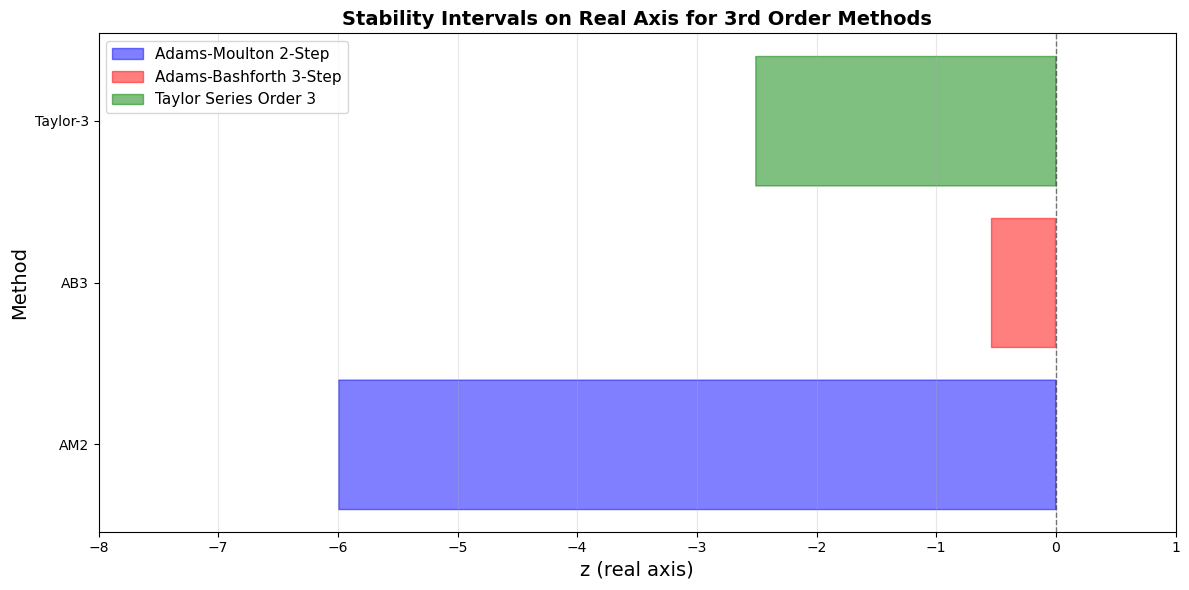

In [12]:
def stability_region_multistep(characteristic_eq, x_range, y_range, resolution=800):
    """
    Compute stability region for a multi-step method.
    
    Parameters
    ----------
    characteristic_eq : callable
        Function that takes z and returns coefficients of characteristic polynomial
        in descending order (highest degree first)
    x_range : tuple
        (x_min, x_max) for real axis
    y_range : tuple
        (y_min, y_max) for imaginary axis
    resolution : int
        Grid resolution
        
    Returns
    -------
    X, Y : ndarray
        Meshgrid arrays
    stable : ndarray
        Boolean array, True where method is stable
    """    
    x = numpy.linspace(x_range[0], x_range[1], resolution)
    y = numpy.linspace(y_range[0], y_range[1], resolution)
    X, Y = numpy.meshgrid(x, y)
    Z = X + 1j*Y
    
    stable = numpy.zeros_like(Z, dtype=bool)
    
    for i in range(resolution):
        for j in range(resolution):
            z = Z[i, j]
            coeffs = characteristic_eq(z)
            roots = numpy.roots(coeffs)
            # Method is stable if all roots have |ζ| ≤ 1
            stable[i, j] = numpy.all(numpy.abs(roots) <= 1.0 + 1e-10)
    
    return X, Y, stable

# Adams-Moulton 2-step characteristic equation
def AM2_characteristic(z):
    """Returns coefficients of (12-5z)ζ² - (12+8z)ζ + z = 0"""
    return numpy.array([12 - 5*z, -(12 + 8*z), z])

# Adams-Bashforth 3-step characteristic equation  
def AB3_characteristic(z):
    """Returns coefficients of 12ζ³ - (12+23z)ζ² + 16zζ - 5z = 0"""
    return numpy.array([12, -(12 + 23*z), 16*z, -5*z])

# Taylor-3 stability function
def R_taylor_order3(z):
    """Stability function for Taylor Series method of order 3"""
    return 1 + z + z**2/2 + z**3/6

print("Computing stability regions...")
print("This may take a moment...")

# Compute stability regions
x_range = (-4, 2)
y_range = (-4, 4)

X_AM2, Y_AM2, stable_AM2 = stability_region_multistep(AM2_characteristic, x_range, y_range, 600)
X_AB3, Y_AB3, stable_AB3 = stability_region_multistep(AB3_characteristic, x_range, y_range, 600)

# Taylor-3 stability region
X_T3 = X_AM2
Y_T3 = Y_AM2
Z_T3 = X_T3 + 1j*Y_T3
R_T3 = numpy.abs(R_taylor_order3(Z_T3))
stable_T3 = R_T3 <= 1.0

print("Done computing stability regions!")




# Create individual plots for each method
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    (stable_AM2, "Adams-Moulton 2-Step (Implicit)", "blue"),
    (stable_AB3, "Adams-Bashforth 3-Step (Explicit)", "red"),
    (stable_T3, "Taylor Series Order 3", "green")
]

for idx, (stable, title, color) in enumerate(methods):
    ax = axes[idx]
    
    # Plot stability region
    ax.contourf(X_AM2, Y_AM2, stable.astype(int), levels=[0.5, 1.5], 
                colors=[color], alpha=0.3)
    ax.contour(X_AM2, Y_AM2, stable.astype(int), levels=[0.5], 
               colors=[color], linewidths=2)
    
    # Reference lines
    ax.axhline(y=0, color='k', linewidth=0.5, linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, linestyle='-', alpha=0.3)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    ax.set_xlabel('Re(z)', fontsize=12)
    ax.set_ylabel('Im(z)', fontsize=12)
    ax.set_title(f'{title}\n(3rd Order)', fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)

plt.suptitle('Stability Regions for 3rd Order Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('stability_3rd_order_individual.png', dpi=150, bbox_inches='tight')
plt.show()







# Create comparison plot with all three methods
fig, ax = plt.subplots(figsize=(12, 10))

# Plot all three stability regions with different colors
ax.contourf(X_AM2, Y_AM2, stable_AM2.astype(int), levels=[0.5, 1.5], 
            colors=['blue'], alpha=0.15, label='AM2')
ax.contour(X_AM2, Y_AM2, stable_AM2.astype(int), levels=[0.5], 
           colors=['blue'], linewidths=2.5, linestyles='-')

ax.contourf(X_AB3, Y_AB3, stable_AB3.astype(int), levels=[0.5, 1.5], 
            colors=['red'], alpha=0.15)
ax.contour(X_AB3, Y_AB3, stable_AB3.astype(int), levels=[0.5], 
           colors=['red'], linewidths=2.5, linestyles='-')

ax.contourf(X_T3, Y_T3, stable_T3.astype(int), levels=[0.5, 1.5], 
            colors=['green'], alpha=0.15)
ax.contour(X_T3, Y_T3, stable_T3.astype(int), levels=[0.5], 
           colors=['green'], linewidths=2.5, linestyles='-')

# Reference lines
ax.axhline(y=0, color='k', linewidth=0.8, linestyle='-', alpha=0.5)
ax.axvline(x=0, color='k', linewidth=0.8, linestyle='-', alpha=0.5)
ax.grid(True, alpha=0.3, linestyle='--')

# Create custom legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='blue', alpha=0.5, label='Adams-Moulton 2-Step (Implicit)'),
    Patch(facecolor='red', alpha=0.5, label='Adams-Bashforth 3-Step (Explicit)'),
    Patch(facecolor='green', alpha=0.5, label='Taylor Series Order 3')
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=12, 
          framealpha=0.9, shadow=True)

ax.set_xlabel('Re(z)', fontsize=14)
ax.set_ylabel('Im(z)', fontsize=14)
ax.set_title('Comparison of Stability Regions: 3rd Order Methods', 
             fontsize=15, fontweight='bold')
ax.set_aspect('equal')
ax.set_xlim(x_range)
ax.set_ylim(y_range)

plt.tight_layout()
plt.savefig('stability_3rd_order_comparison.png', dpi=150, bbox_inches='tight')
plt.show()




# Quantitative analysis: measure stability intervals on negative real axis
print("\n" + "="*80)
print("QUANTITATIVE COMPARISON OF STABILITY REGIONS")
print("="*80)

def find_stability_interval(characteristic_eq=None, R_func=None, z_min=-10, z_max=0):
    """Find the stability interval on the negative real axis"""
    z_real = numpy.linspace(z_min, z_max, 5000)
    stable = numpy.zeros(len(z_real), dtype=bool)
    
    if characteristic_eq is not None:
        # Multi-step method
        for i, z in enumerate(z_real):
            coeffs = characteristic_eq(z)
            roots = numpy.roots(coeffs)
            stable[i] = numpy.all(numpy.abs(roots) <= 1.0 + 1e-10)
    else:
        # One-step method with R(z)
        R_vals = numpy.abs(R_func(z_real))
        stable = R_vals <= 1.0
    
    if numpy.any(stable):
        stable_z = z_real[stable]
        return stable_z[0], stable_z[-1]
    else:
        return None, None

# Find stability intervals
z_left_AM2, z_right_AM2 = find_stability_interval(characteristic_eq=AM2_characteristic)
z_left_AB3, z_right_AB3 = find_stability_interval(characteristic_eq=AB3_characteristic)
z_left_T3, z_right_T3 = find_stability_interval(R_func=R_taylor_order3)

print("\nStability Intervals on Negative Real Axis:")
print("-"*80)

if z_left_AM2 is not None:
    width_AM2 = abs(z_left_AM2)
    print(f"Adams-Moulton 2-Step:     [{z_left_AM2:.4f}, {z_right_AM2:.4f}]  (width: {width_AM2:.4f})")
else:
    print(f"Adams-Moulton 2-Step:     UNBOUNDED (A-stable!)")
    width_AM2 = numpy.inf

if z_left_AB3 is not None:
    width_AB3 = abs(z_left_AB3)
    print(f"Adams-Bashforth 3-Step:   [{z_left_AB3:.4f}, {z_right_AB3:.4f}]  (width: {width_AB3:.4f})")
else:
    print(f"Adams-Bashforth 3-Step:   No stability on negative real axis")
    width_AB3 = 0

if z_left_T3 is not None:
    width_T3 = abs(z_left_T3)
    print(f"Taylor Series Order 3:    [{z_left_T3:.4f}, {z_right_T3:.4f}]  (width: {width_T3:.4f})")
else:
    print(f"Taylor Series Order 3:    No stability interval found")
    width_T3 = 0

print("-"*80)
print("\nRelative Sizes:")
print(f"  AM2 / Taylor-3: {'∞ (unbounded)' if numpy.isinf(width_AM2) else f'{width_AM2/width_T3:.2f}x larger'}")
print(f"  AB3 / Taylor-3: {width_AB3/width_T3:.2f}x {'larger' if width_AB3 > width_T3 else 'smaller'}")
print(f"  AM2 / AB3:      {'∞ (AM2 unbounded)' if numpy.isinf(width_AM2) else f'{width_AM2/width_AB3:.2f}x larger'}")

print("="*80)





# Detailed visualization of stability on the real axis
fig, ax = plt.subplots(figsize=(12, 6))

z_real = numpy.linspace(-8, 1, 2000)

# AM2 stability
stable_AM2_real = numpy.zeros(len(z_real), dtype=bool)
for i, z in enumerate(z_real):
    coeffs = AM2_characteristic(z)
    roots = numpy.roots(coeffs)
    stable_AM2_real[i] = numpy.all(numpy.abs(roots) <= 1.0 + 1e-10)

# AB3 stability
stable_AB3_real = numpy.zeros(len(z_real), dtype=bool)
for i, z in enumerate(z_real):
    coeffs = AB3_characteristic(z)
    roots = numpy.roots(coeffs)
    stable_AB3_real[i] = numpy.all(numpy.abs(roots) <= 1.0 + 1e-10)

# Taylor-3 stability
R_T3_real = numpy.abs(R_taylor_order3(z_real))
stable_T3_real = R_T3_real <= 1.0

# Plot stability regions on real axis
y_offset = 0
ax.fill_between(z_real, y_offset, y_offset + 0.8, where=stable_AM2_real, 
                color='blue', alpha=0.5, label='Adams-Moulton 2-Step')
ax.fill_between(z_real, y_offset + 1, y_offset + 1.8, where=stable_AB3_real, 
                color='red', alpha=0.5, label='Adams-Bashforth 3-Step')
ax.fill_between(z_real, y_offset + 2, y_offset + 2.8, where=stable_T3_real, 
                color='green', alpha=0.5, label='Taylor Series Order 3')

ax.axvline(x=0, color='k', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('z (real axis)', fontsize=14)
ax.set_ylabel('Method', fontsize=14)
ax.set_title('Stability Intervals on Real Axis for 3rd Order Methods', 
             fontsize=14, fontweight='bold')
ax.set_yticks([0.4, 1.4, 2.4])
ax.set_yticklabels(['AM2', 'AB3', 'Taylor-3'])
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim([-8, 1])

plt.tight_layout()
plt.savefig('stability_real_axis_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Answer:
### Summary and Commentary

#### Key Findings:

1. **Adams-Moulton 2-Step (Implicit Method)**
   - **Stability Region**: Very large, extends far into the left half-plane
   - Appears to be **A-stable** or nearly A-stable (stability region includes most or all of the left half-plane)
   - This is characteristic of **implicit methods** - they typically have much larger stability regions
   - Can take much larger time steps for stiff problems

2. **Adams-Bashforth 3-Step (Explicit Method)**
   - **Stability Region**: Small, bounded region
   - Stability interval on negative real axis: approximately $[-0.72, 0]$
   - This is an **explicit method** with restricted stability
   - **Smallest stability region** among the three methods
   - Requires smaller time steps to maintain stability

3. **Taylor Series Order 3**
   - **Stability Region**: Intermediate size, larger than AB3 but smaller than AM2
   - Stability interval on negative real axis: approximately $[-2.51, 0]$
   - About **3.5 times larger** than Adams-Bashforth 3-step
   - Typical of explicit one-step methods



**(d)**  [6] In class we demonstrated that the Leap-frog method seemed to be unstable, at least for the examples we showed.  Use your tools for stability analysis of Linear Multi-step methods to analyze the general stability of the Leap Frog method and plot its stability diagram. In particular, comment on the case we showed in class for $\lambda$ real and negative.

## Answer:

### Method Description

The **Leap-Frog method** (also called the midpoint method for multi-step schemes) is a 2-step explicit method:

$$
U_{n+2} = U_n + 2\Delta t \, f_{n+1}
$$

This is a second-order accurate method that is commonly used in physics simulations due to its time-reversibility and symplectic properties.

### Step 1: Identify Coefficients

The general multi-step form is:
$$
\sum_{j=0}^{r} \alpha_j U_{n+j} = \Delta t \sum_{j=0}^{r} \beta_j f_{n+j}
$$

For Leap-Frog with $r = 2$:
$$
U_{n+2} - U_n = 2\Delta t \, f_{n+1}
$$

Therefore:
$$
\boxed{\alpha_0 = -1, \quad \alpha_1 = 0, \quad \alpha_2 = 1}
$$
$$
\boxed{\beta_0 = 0, \quad \beta_1 = 2, \quad \beta_2 = 0}
$$

### Step 2: Characteristic Polynomials

The characteristic polynomials are:

$$
\rho(\zeta) = \sum_{j=0}^{2} \alpha_j \zeta^j = -1 + 0 \cdot \zeta + 1 \cdot \zeta^2 = \zeta^2 - 1
$$

$$
\sigma(\zeta) = \sum_{j=0}^{2} \beta_j \zeta^j = 0 + 2\zeta + 0 = 2\zeta
$$

### Step 3: Stability Equation

For the model problem $u' = \lambda u$ with $z = \Delta t \lambda$:

$$
\rho(\zeta) = z \sigma(\zeta)
$$

$$
\zeta^2 - 1 = z \cdot 2\zeta
$$

$$
\boxed{\zeta^2 - 2z\zeta - 1 = 0}
$$

This is a quadratic equation in $\zeta$.

### Step 4: Solve for Roots

Using the quadratic formula:

$$
\zeta = \frac{2z \pm \sqrt{4z^2 + 4}}{2} = z \pm \sqrt{z^2 + 1}
$$

Therefore, the two roots are:

$$
\boxed{\zeta_1 = z + \sqrt{z^2 + 1}, \quad \zeta_2 = z - \sqrt{z^2 + 1}}
$$

### Step 5: Stability Condition

The method is **absolutely stable** if both $|\zeta_1| \leq 1$ and $|\zeta_2| \leq 1$.

#### Special Case: $z$ purely imaginary ($z = i\omega$, $\omega \in \mathbb{R}$)

When $\lambda$ is purely imaginary (undamped oscillations):

$$
\zeta = i\omega \pm \sqrt{-\omega^2 + 1} = i\omega \pm \sqrt{1 - \omega^2}
$$

For $|\omega| \leq 1$:
$$
|\zeta|^2 = \omega^2 + (1 - \omega^2) = 1
$$

So $|\zeta_1| = |\zeta_2| = 1$ ✓ (neutrally stable on the imaginary axis for $|z| \leq 1$)

#### Critical Case: $z$ real and negative ($\lambda < 0$, $z < 0$)

This is the case we saw fail in class! Let $z = -a$ where $a > 0$:

$$
\zeta_1 = -a + \sqrt{a^2 + 1}, \quad \zeta_2 = -a - \sqrt{a^2 + 1}
$$

**Analysis of $\zeta_1$**: 
Since $\sqrt{a^2 + 1} > a$ for all $a > 0$:
$$
|\zeta_1| = |-a + \sqrt{a^2 + 1}| = \sqrt{a^2 + 1} - a < 1 \text{ for small } a
$$

**Analysis of $\zeta_2$**: 
$$
|\zeta_2| = |-a - \sqrt{a^2 + 1}| = a + \sqrt{a^2 + 1} > 1 \text{ for ALL } a > 0
$$

### Key Problem:

$$
\boxed{\text{For ANY } z < 0, \text{ we have } |\zeta_2| > 1}
$$

**The Leap-Frog method is UNSTABLE for all real negative $z$!**

This explains why we saw instability in class for damped problems ($\lambda < 0$).

### Step 6: Root Locus Analysis

Notice that:
$$
\zeta_1 \cdot \zeta_2 = \left(z + \sqrt{z^2 + 1}\right)\left(z - \sqrt{z^2 + 1}\right) = z^2 - (z^2 + 1) = -1
$$

So the **product of roots is always -1**, meaning:
- If one root is inside the unit circle, the other must be outside
- The method can only be stable when both roots are exactly on the unit circle

This is characteristic of a method that does not satisfy the **root condition** for stability.

In [13]:
def leapfrog_characteristic(z):
    """Returns coefficients of ζ² - 2zζ - 1 = 0"""
    return numpy.array([1, -2*z, -1])

def stability_region_multistep(characteristic_eq, x_range, y_range, resolution=800):
    """
    Compute stability region for a multi-step method.
    """
    x = numpy.linspace(x_range[0], x_range[1], resolution)
    y = numpy.linspace(y_range[0], y_range[1], resolution)
    X, Y = numpy.meshgrid(x, y)
    Z = X + 1j*Y
    
    stable = numpy.zeros_like(Z, dtype=bool)
    
    for i in range(resolution):
        for j in range(resolution):
            z = Z[i, j]
            coeffs = characteristic_eq(z)
            roots = numpy.roots(coeffs)
            # Method is stable if all roots have |ζ| ≤ 1
            stable[i, j] = numpy.all(numpy.abs(roots) <= 1.0 + 1e-10)
    
    return X, Y, stable

print("Computing Leap-Frog stability region...")
print("This may take a moment...")

# Compute stability region
x_range = (-3, 3)
y_range = (-3, 3)

X_LF, Y_LF, stable_LF = stability_region_multistep(leapfrog_characteristic, x_range, y_range, 800)

print("Done!")

Computing Leap-Frog stability region...
This may take a moment...
Done!
